<a href="https://colab.research.google.com/github/s24118-ui/ASI/blob/main/Projekt_ASI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Score
---

## 1. Import i ładowanie danych


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/ASI')

df = pd.read_csv('data.csv', sep=',')
df.info()

Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan       

/tmp/ipykernel_1734/1797980452.py:10: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data.csv', sep=',')


## 2. Analiza identyfikacji klienta


In [2]:
print(f"Number of unique Customer_ID values: {df['Customer_ID'].nunique()}")
duplicate_customer_ids = df[df.duplicated(subset=['Customer_ID'], keep=False)]

Number of unique Customer_ID values: 12500


## 3. Przegląd początkowych brakujących wartości


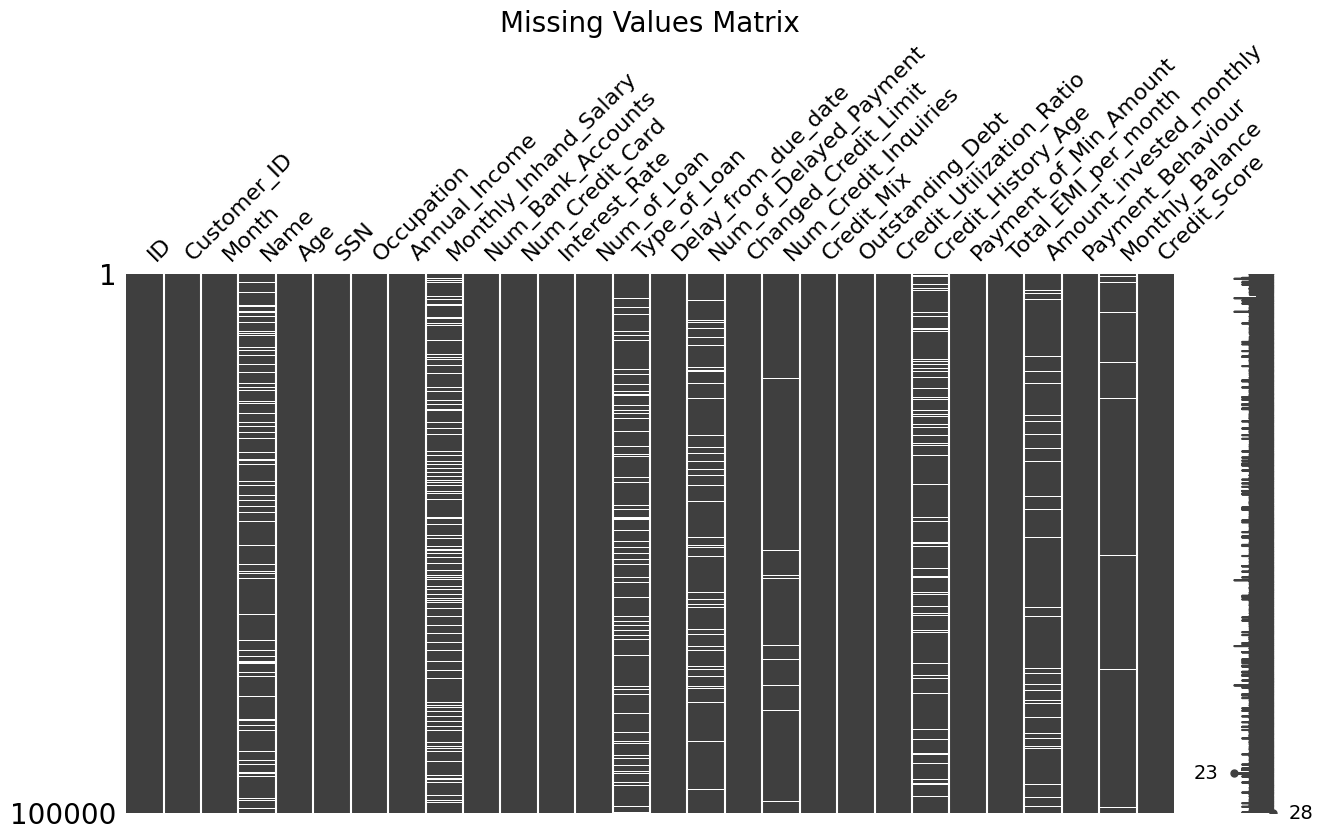

In [3]:
msno.matrix(df, figsize=(15, 7))
plt.title('Missing Values Matrix', fontsize=20)
plt.show()

In [4]:
display(df.head(20))

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
5,0x1607,CUS_0xd40,June,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,27.262259,22 Years and 6 Months,No,49.574949,62.430172331195294,!@9#%8,340.4792117872438,Good
6,0x1608,CUS_0xd40,July,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,22.537593,22 Years and 7 Months,No,49.574949,178.3440674122349,Low_spent_Small_value_payments,244.5653167062043,Good
7,0x1609,CUS_0xd40,August,NaN,23,#F%$D@*&8,Scientist,19114.12,1824.843333,3,...,Good,809.98,23.933795,NaN,No,49.574949,24.785216509052056,High_spent_Medium_value_payments,358.12416760938714,Standard
8,0x160e,CUS_0x21b1,January,Rick Rothackerj,28_,004-07-5839,_______,34847.84,3037.986667,2,...,Good,605.03,24.464031,26 Years and 7 Months,No,18.816215,104.291825168246,Low_spent_Small_value_payments,470.69062692529184,Standard
9,0x160f,CUS_0x21b1,February,Rick Rothackerj,28,004-07-5839,Teacher,34847.84,3037.986667,2,...,Good,605.03,38.550848,26 Years and 8 Months,No,18.816215,40.39123782853101,High_spent_Large_value_payments,484.5912142650067,Good


Now, let's address the missing `Monthly_Inhand_Salary` values by grouping by `Customer_ID`. We will fill the missing salaries for a customer with a non-missing salary value available for that same customer. After this, we will recheck the `df.info()` to see the improvement in data completeness.

In [5]:
df['Monthly_Inhand_Salary'] = df.groupby('Customer_ID')['Monthly_Inhand_Salary'].transform(lambda x: x.ffill().bfill())

df.info()
display(df.head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
5,0x1607,CUS_0xd40,June,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,27.262259,22 Years and 6 Months,No,49.574949,62.430172331195294,!@9#%8,340.4792117872438,Good
6,0x1608,CUS_0xd40,July,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,22.537593,22 Years and 7 Months,No,49.574949,178.3440674122349,Low_spent_Small_value_payments,244.5653167062043,Good
7,0x1609,CUS_0xd40,August,NaN,23,#F%$D@*&8,Scientist,19114.12,1824.843333,3,...,Good,809.98,23.933795,NaN,No,49.574949,24.785216509052056,High_spent_Medium_value_payments,358.12416760938714,Standard
8,0x160e,CUS_0x21b1,January,Rick Rothackerj,28_,004-07-5839,_______,34847.84,3037.986667,2,...,Good,605.03,24.464031,26 Years and 7 Months,No,18.816215,104.291825168246,Low_spent_Small_value_payments,470.69062692529184,Standard
9,0x160f,CUS_0x21b1,February,Rick Rothackerj,28,004-07-5839,Teacher,34847.84,3037.986667,2,...,Good,605.03,38.550848,26 Years and 8 Months,No,18.816215,40.39123782853101,High_spent_Large_value_payments,484.5912142650067,Good


### 4.1 Age


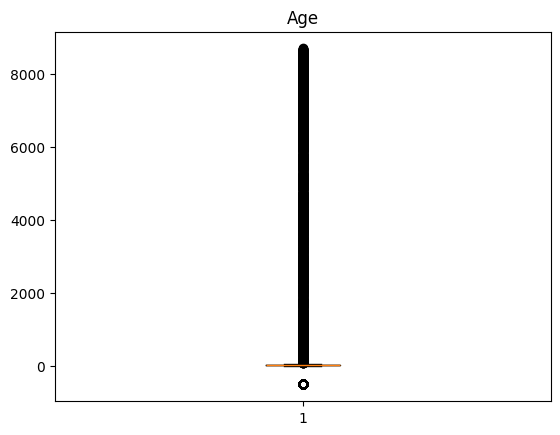

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

plt.boxplot(df['Age'].dropna())
plt.title("Age")
plt.show()

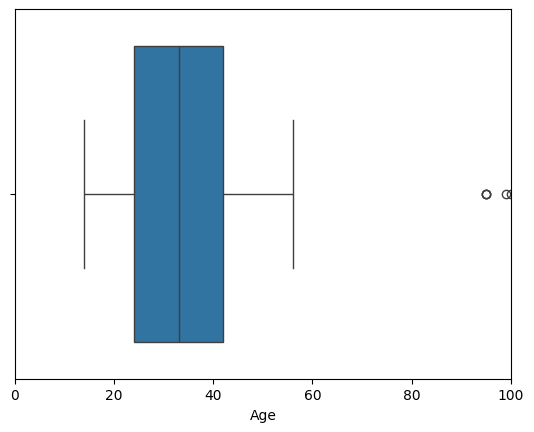

In [7]:
sns.boxplot(x=df["Age"])
plt.xlim(0, 100)
plt.show()

In [8]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age'] = df['Age'].apply(lambda x: x if 0 <= x <= 90 else pd.NA)

df['Age'] = df.groupby('Customer_ID')['Age'].transform(lambda x: x.ffill().bfill())

print(df['Age'].describe())

/tmp/ipykernel_1734/1604008595.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Age'] = df.groupby('Customer_ID')['Age'].transform(lambda x: x.ffill().bfill())


count    100000.00000
mean         33.30638
std          10.76514
min          14.00000
25%          24.00000
50%          33.00000
75%          42.00000
max          56.00000
Name: Age, dtype: float64


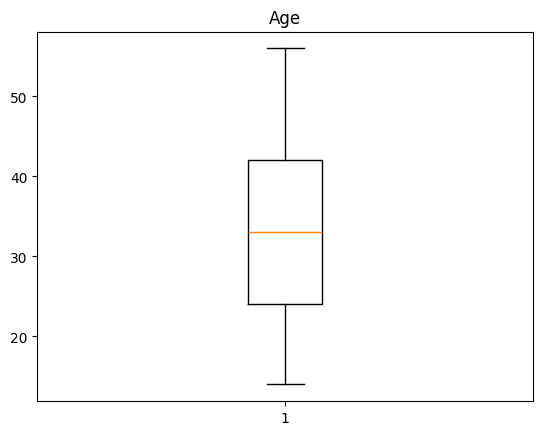

In [9]:
plt.boxplot(df['Age'])
plt.title("Age")
plt.show()

In [10]:
nan_age_count = df['Age'].isnull().sum()
print(f"{nan_age_count}")

0


### Macierz wartości brakujących po ustaleniu 'Age'


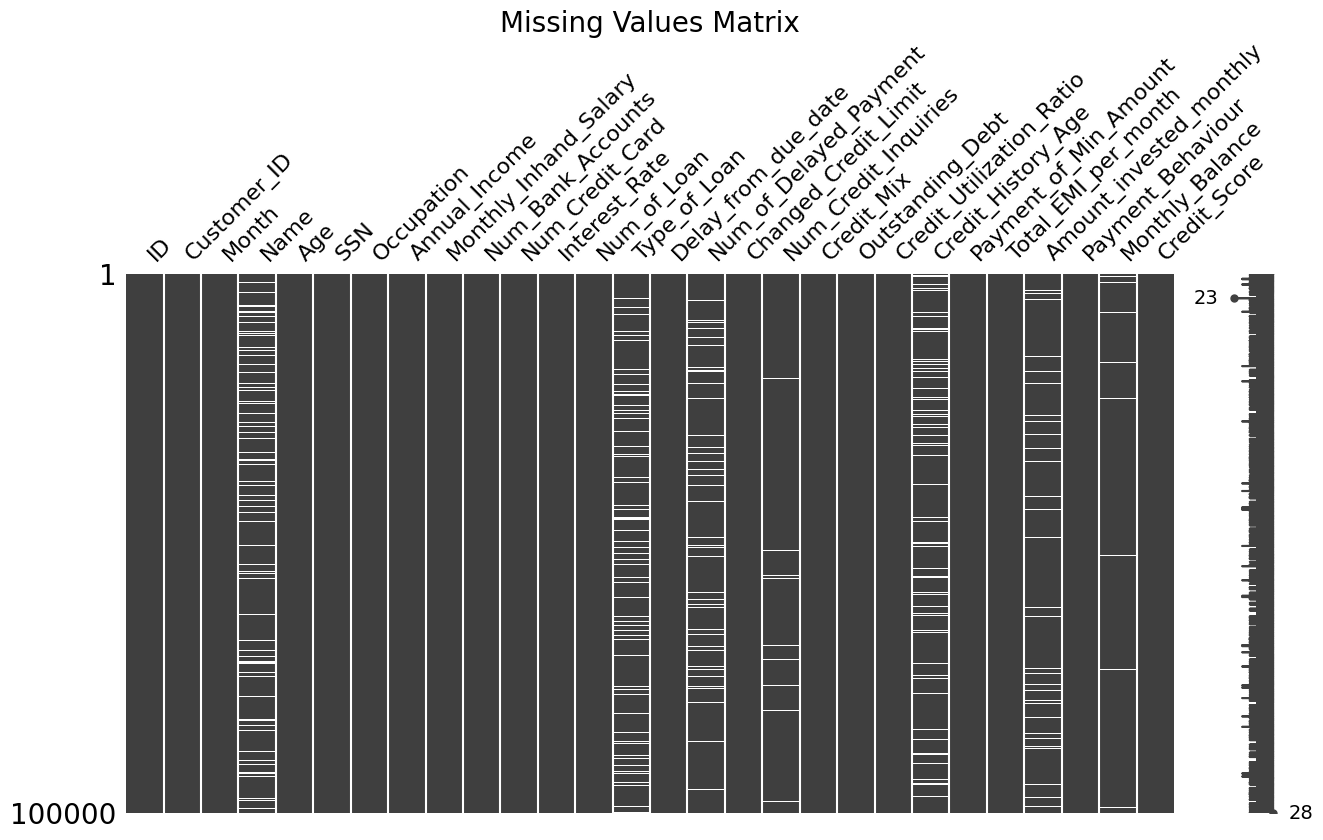

In [11]:
msno.matrix(df, figsize=(15, 7))
plt.title('Missing Values Matrix', fontsize=20)
plt.show()

### Podgląd danych po oczyszczeniu 'Age'


In [12]:
pd.set_option('display.max_columns', None)
display(df.head(50))

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.0,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.0,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,_,4.0,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4,6.27,4.0,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.0,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
5,0x1607,CUS_0xd40,June,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",8,4,9.27,4.0,Good,809.98,27.262259,22 Years and 6 Months,No,49.574949,62.430172331195294,!@9#%8,340.4792117872438,Good
6,0x1608,CUS_0xd40,July,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,8_,11.27,4.0,Good,809.98,22.537593,22 Years and 7 Months,No,49.574949,178.3440674122349,Low_spent_Small_value_payments,244.5653167062043,Good
7,0x1609,CUS_0xd40,August,NaN,23.0,#F%$D@*&8,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,6,11.27,4.0,Good,809.98,23.933795,NaN,No,49.574949,24.785216509052056,High_spent_Medium_value_payments,358.12416760938714,Standard
8,0x160e,CUS_0x21b1,January,Rick Rothackerj,28.0,004-07-5839,_______,34847.84,3037.986667,2,4,6,1,Credit-Builder Loan,3,4,5.42,2.0,Good,605.03,24.464031,26 Years and 7 Months,No,18.816215,104.291825168246,Low_spent_Small_value_payments,470.69062692529184,Standard
9,0x160f,CUS_0x21b1,February,Rick Rothackerj,28.0,004-07-5839,Teacher,34847.84,3037.986667,2,4,6,1,Credit-Builder Loan,7,1,7.42,2.0,Good,605.03,38.550848,26 Years and 8 Months,No,18.816215,40.39123782853101,High_spent_Large_value_payments,484.5912142650067,Good


### 4.2 Num_Bank_Accounts


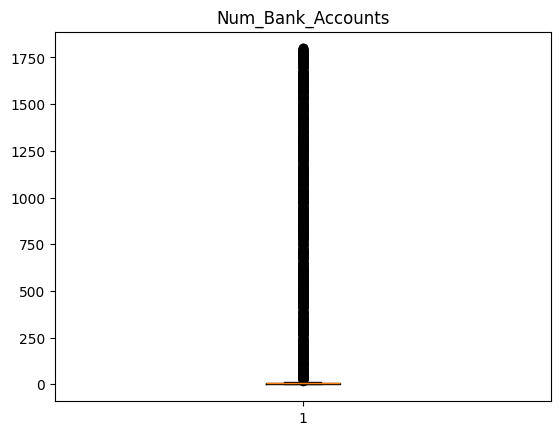

In [13]:
plt.boxplot(df['Num_Bank_Accounts'])
plt.title("Num_Bank_Accounts")
plt.show()

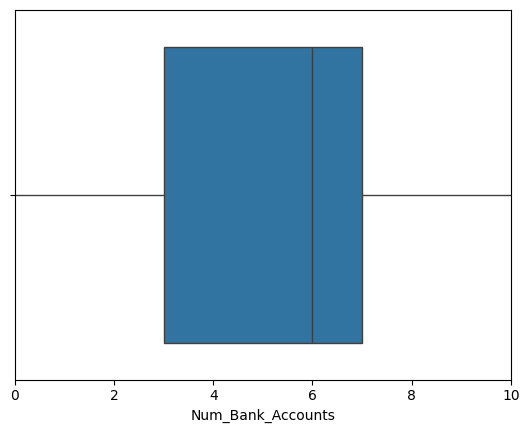

In [14]:
sns.boxplot(x=df["Num_Bank_Accounts"])
plt.xlim(0, 10)
plt.show()

In [15]:
negative_bank_accounts = df[df['Num_Bank_Accounts'] < 0]
print(negative_bank_accounts)

            ID Customer_ID     Month            Name   Age          SSN  \
30330   0xc7b8  CUS_0x4f2a     March       Margaretf  39.0  807-03-5415   
30331   0xc7b9  CUS_0x4f2a     April       Margaretf  40.0    #F%$D@*&8   
30332   0xc7ba  CUS_0x4f2a       May       Margaretf  40.0  807-03-5415   
30333   0xc7bb  CUS_0x4f2a      June       Margaretf  40.0  807-03-5415   
30334   0xc7bc  CUS_0x4f2a      July       Margaretf  40.0  807-03-5415   
30335   0xc7bd  CUS_0x4f2a    August       Margaretf  40.0  807-03-5415   
43689  0x115ff  CUS_0xa878  February  Douwe Miedemaz  54.0  300-54-4627   
43690  0x11600  CUS_0xa878     March  Douwe Miedemaz  54.0  300-54-4627   
43691  0x11601  CUS_0xa878     April  Douwe Miedemaz  54.0  300-54-4627   
43692  0x11602  CUS_0xa878       May  Douwe Miedemaz  54.0  300-54-4627   
43693  0x11603  CUS_0xa878      June  Douwe Miedemaz  54.0  300-54-4627   
43694  0x11604  CUS_0xa878      July  Douwe Miedemaz  54.0  300-54-4627   
43695  0x11605  CUS_0xa87

In [16]:
print(f"{len(negative_bank_accounts)}")

21


In [17]:
df = df[df['Num_Bank_Accounts'] >= 0]

In [18]:
weird_bank_accounts = df[df['Num_Bank_Accounts'] > 10]
print(f"{len(weird_bank_accounts)}")

1324


In [19]:
import numpy as np
df.loc[df['Num_Bank_Accounts'] > 10, 'Num_Bank_Accounts'] = np.nan
df.loc[df['Num_Bank_Accounts'] < 0, 'Num_Bank_Accounts'] = np.nan

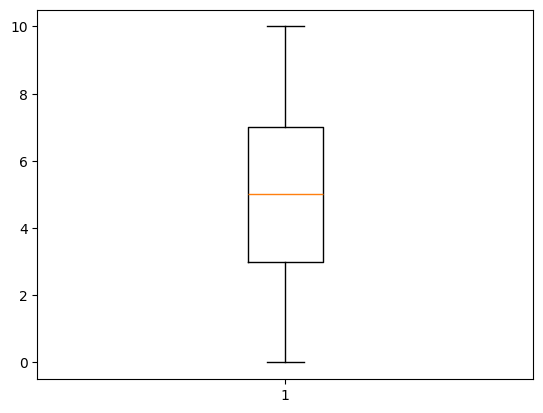

In [20]:
plt.boxplot(df['Num_Bank_Accounts'].dropna())
plt.show()

In [21]:
print(df['Num_Bank_Accounts'].describe())

count    98655.000000
mean         5.368466
std          2.592011
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: Num_Bank_Accounts, dtype: float64


### 4.3 Num_Credit_Card


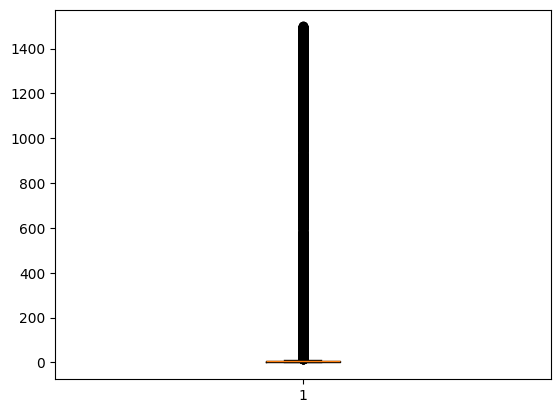

In [22]:
plt.boxplot(df['Num_Credit_Card'].dropna())
plt.show()

In [23]:
count = (df['Num_Credit_Card'] > 20).sum()
print(count)

2262


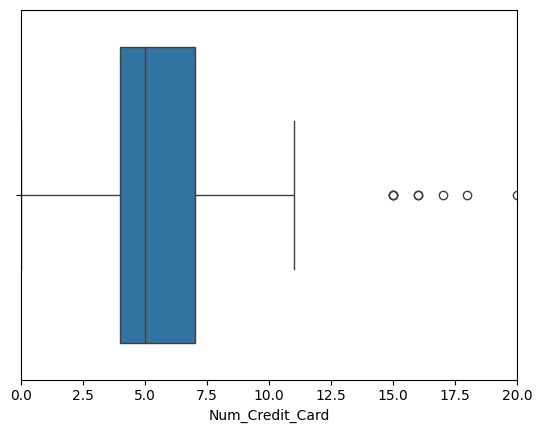

In [24]:
sns.boxplot(x=df["Num_Credit_Card"])
plt.xlim(0, 20)
plt.show()

In [25]:
df.loc[df['Num_Credit_Card'] > 13, 'Num_Credit_Card'] = np.nan

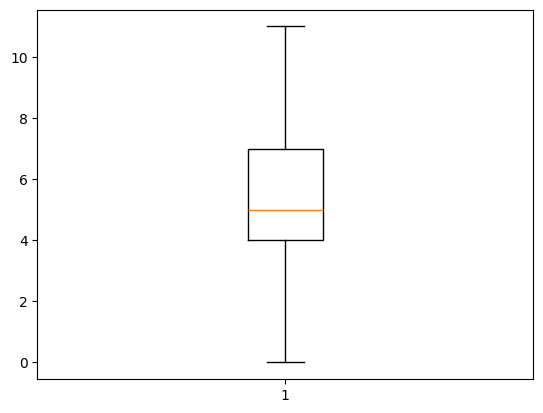

In [26]:
plt.boxplot(df['Num_Credit_Card'].dropna())
plt.show()

In [27]:
count = (df['Num_Credit_Card']).isnull().sum()
print(count)

2270


In [28]:
df['Num_Bank_Accounts'] = df.groupby('Customer_ID')['Num_Bank_Accounts'].transform(lambda x: x.ffill().bfill())
print(f"{df['Num_Bank_Accounts'].isnull().sum()}")

0


In [29]:
df['Num_Credit_Card'] = df.groupby('Customer_ID')['Num_Credit_Card'].transform(lambda x: x.ffill().bfill())
print(f"{df['Num_Credit_Card'].isnull().sum()}")

0


### Informacje o danych po czyszczeniu "Num_Bank_Accounts" i "Num_Credit_Card"


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99979 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        99979 non-null  object 
 1   Customer_ID               99979 non-null  object 
 2   Month                     99979 non-null  object 
 3   Name                      89997 non-null  object 
 4   Age                       99979 non-null  float64
 5   SSN                       99979 non-null  object 
 6   Occupation                99979 non-null  object 
 7   Annual_Income             99979 non-null  object 
 8   Monthly_Inhand_Salary     99979 non-null  float64
 9   Num_Bank_Accounts         99979 non-null  float64
 10  Num_Credit_Card           99979 non-null  float64
 11  Interest_Rate             99979 non-null  int64  
 12  Num_of_Loan               99979 non-null  object 
 13  Type_of_Loan              88578 non-null  object 
 14  Delay_from_

### Macierz brakujących wartości po naprawie rachunku bankowego i karty kredytowej


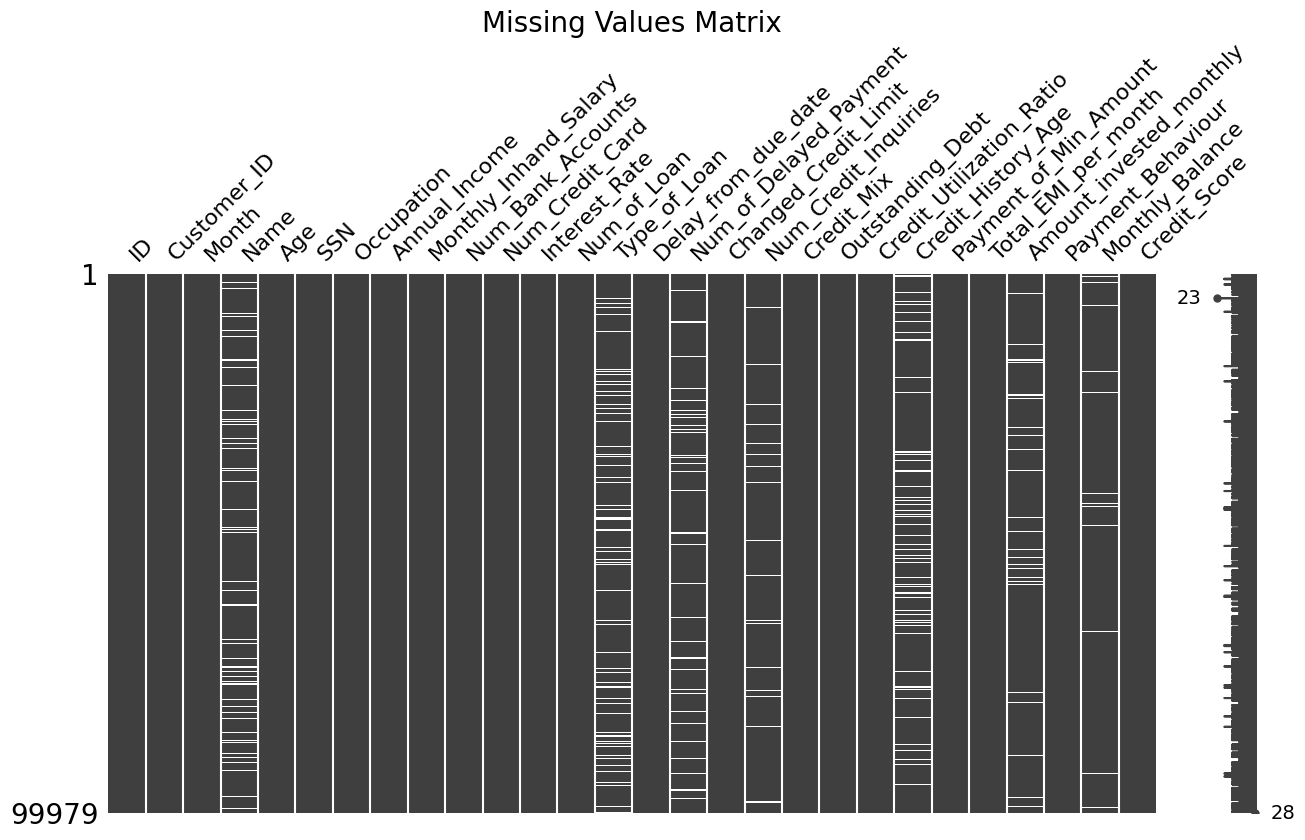

In [31]:
msno.matrix(df, figsize=(15, 7))
plt.title('Missing Values Matrix', fontsize=20)
plt.show()

### 4.4 Interest_Rate


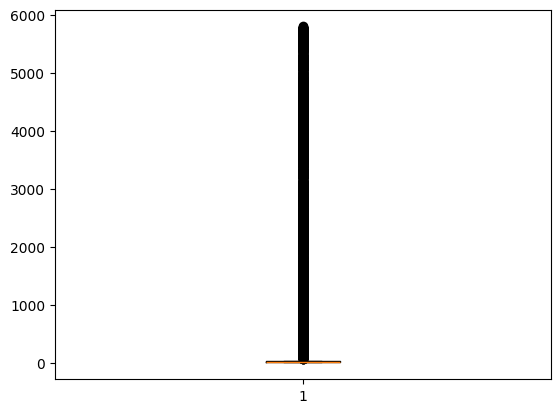

In [32]:
plt.boxplot(df['Interest_Rate'].dropna())
plt.show()

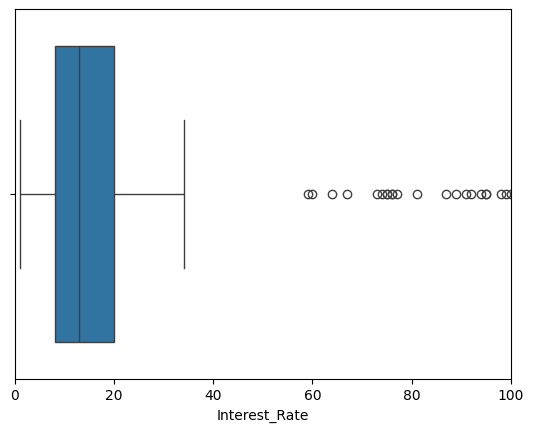

In [33]:
sns.boxplot(x=df["Interest_Rate"])
plt.xlim(0, 100)
plt.show()

In [34]:
interest_rate_gt_50 = df[df['Interest_Rate'] > 40]
print(f"{len(interest_rate_gt_50)}")

2034


In [35]:
print(df['Interest_Rate'].describe())

count    99979.000000
mean        72.480271
std        466.470569
min          1.000000
25%          8.000000
50%         13.000000
75%         20.000000
max       5797.000000
Name: Interest_Rate, dtype: float64


In [36]:
df.loc[df['Interest_Rate'] > 40, 'Interest_Rate'] = np.nan
df['Interest_Rate'] = df.groupby('Customer_ID')['Interest_Rate'].transform(lambda x: x.ffill().bfill())

In [37]:
print(df['Interest_Rate'].describe())
print(f"{df['Interest_Rate'].isnull().sum()}")

count    99979.000000
mean        14.534142
std          8.741009
min          1.000000
25%          7.000000
50%         13.000000
75%         20.000000
max         34.000000
Name: Interest_Rate, dtype: float64
0


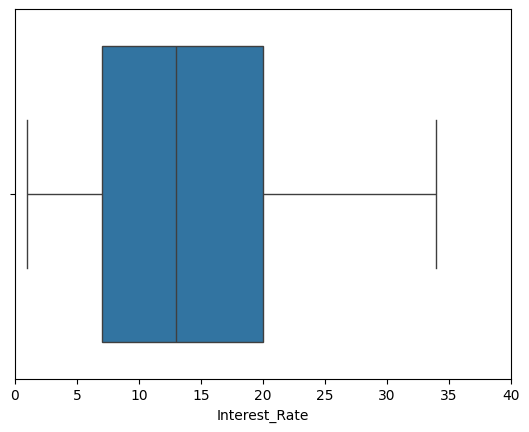

In [38]:
sns.boxplot(x=df["Interest_Rate"])
plt.xlim(0, 40)
plt.show()

### 4.5 Num_of_Loan


count     99979
unique      434
top           3
freq      14382
Name: Num_of_Loan, dtype: object


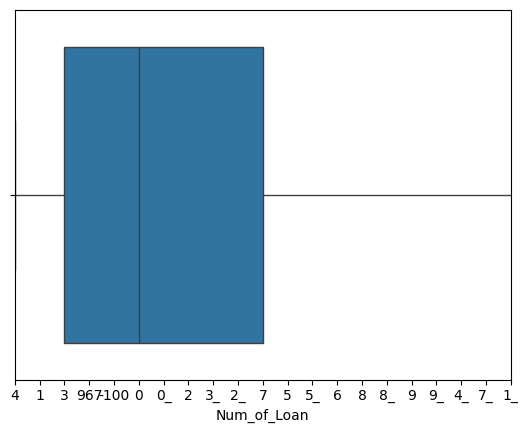

In [39]:
print(df['Num_of_Loan'].describe())
sns.boxplot(x=df["Num_of_Loan"])
plt.xlim(0, 20)
plt.show()


In [40]:
df['Num_of_Loan'] = df['Num_of_Loan'].astype(str).str.replace(r'[^\d.]', '', regex=True)
df['Num_of_Loan'] = pd.to_numeric(df['Num_of_Loan'], errors='coerce')
df['Num_of_Loan'] = df.groupby('Customer_ID')['Num_of_Loan'].transform(lambda x: x.ffill().bfill())

print(df['Num_of_Loan'].describe())
print(f"{df['Num_of_Loan'].isnull().sum()}")

count    99979.000000
mean        10.762950
std         61.795632
min          0.000000
25%          2.000000
50%          3.000000
75%          6.000000
max       1496.000000
Name: Num_of_Loan, dtype: float64
0


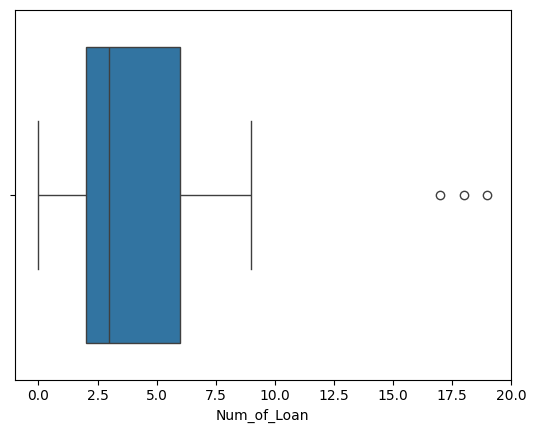

In [41]:
sns.boxplot(x=df["Num_of_Loan"])
plt.xlim(-1, 20)
plt.show()

In [42]:
negative_loans = df[df['Num_of_Loan'] < 0]
print(f"{len(negative_loans)}")
weird_loans = df[df['Num_of_Loan'] >15]
print(f"{len(weird_loans)}")

0
4347


In [43]:
df.loc[df['Num_of_Loan'] > 15, 'Num_of_Loan'] = np.nan
df['Num_of_Loan'] = df.groupby('Customer_ID')['Num_of_Loan'].transform(lambda x: x.ffill().bfill())

weird_loans = df[df['Num_of_Loan'] >15]
print(f"{len(weird_loans)}")

0


## 4.6 Type_of_Loan


In [44]:
print(df['Type_of_Loan'].describe())

count             88578
unique             6260
top       Not Specified
freq               1408
Name: Type_of_Loan, dtype: object


In [45]:
top_50_loan_types = df['Type_of_Loan'].value_counts().head(50)
print(top_50_loan_types)

Type_of_Loan
Not Specified                                           1408
Credit-Builder Loan                                     1280
Personal Loan                                           1272
Debt Consolidation Loan                                 1264
Student Loan                                            1236
Payday Loan                                             1200
Mortgage Loan                                           1176
Auto Loan                                               1152
Home Equity Loan                                        1136
Personal Loan, and Student Loan                          320
Not Specified, and Payday Loan                           272
Mortgage Loan, and Home Equity Loan                      264
Student Loan, and Payday Loan                            256
Credit-Builder Loan, and Not Specified                   248
Student Loan, and Credit-Builder Loan                    248
Payday Loan, and Debt Consolidation Loan                 240
Payday Loan

In [46]:
filled_loans = df['Type_of_Loan'].fillna('Not Specified')

def get_unique_loan_types(loan_string):
    loan_string = loan_string.replace(' and ', ', ')
    types = [t.strip() for t in loan_string.split(',') if t.strip()]
    return types

all_loan_types = filled_loans.apply(get_unique_loan_types).explode()

unique_loan_types_array = all_loan_types.unique()

print("Array of all unique loan types:")
print(unique_loan_types_array)
print(f"Total unique loan types found: {len(unique_loan_types_array)}")

Array of all unique loan types:
['Auto Loan' 'Credit-Builder Loan' 'Personal Loan' 'Home Equity Loan'
 'Not Specified' 'Mortgage Loan' 'Student Loan' 'Debt Consolidation Loan'
 'Payday Loan']
Total unique loan types found: 9


In [47]:
loan_type_dummies = pd.get_dummies(all_loan_types, prefix='LoanType')
loan_type_encoded = loan_type_dummies.groupby(loan_type_dummies.index).sum()
loan_type_encoded = loan_type_encoded.applymap(lambda x: 1 if x > 0 else 0)
df = df.merge(loan_type_encoded, left_index=True, right_index=True, how='left')
df = df.drop(columns=['Type_of_Loan'])
display(df.head())

/tmp/ipykernel_1734/412024649.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  loan_type_encoded = loan_type_encoded.applymap(lambda x: 1 if x > 0 else 0)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,LoanType_Auto Loan,LoanType_Credit-Builder Loan,LoanType_Debt Consolidation Loan,LoanType_Home Equity Loan,LoanType_Mortgage Loan,LoanType_Not Specified,LoanType_Payday Loan,LoanType_Personal Loan,LoanType_Student Loan
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,3,7,11.27,4.0,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good,1,1,0,1,0,0,0,1,0
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,-1,NaN,11.27,4.0,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good,1,1,0,1,0,0,0,1,0
2,0x1604,CUS_0xd40,March,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,3,7,_,4.0,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good,1,1,0,1,0,0,0,1,0
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,5,4,6.27,4.0,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good,1,1,0,1,0,0,0,1,0
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,6,NaN,11.27,4.0,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good,1,1,0,1,0,0,0,1,0


### Macierz brakujących wartości po kodowaniu 'Type_of_Loan'


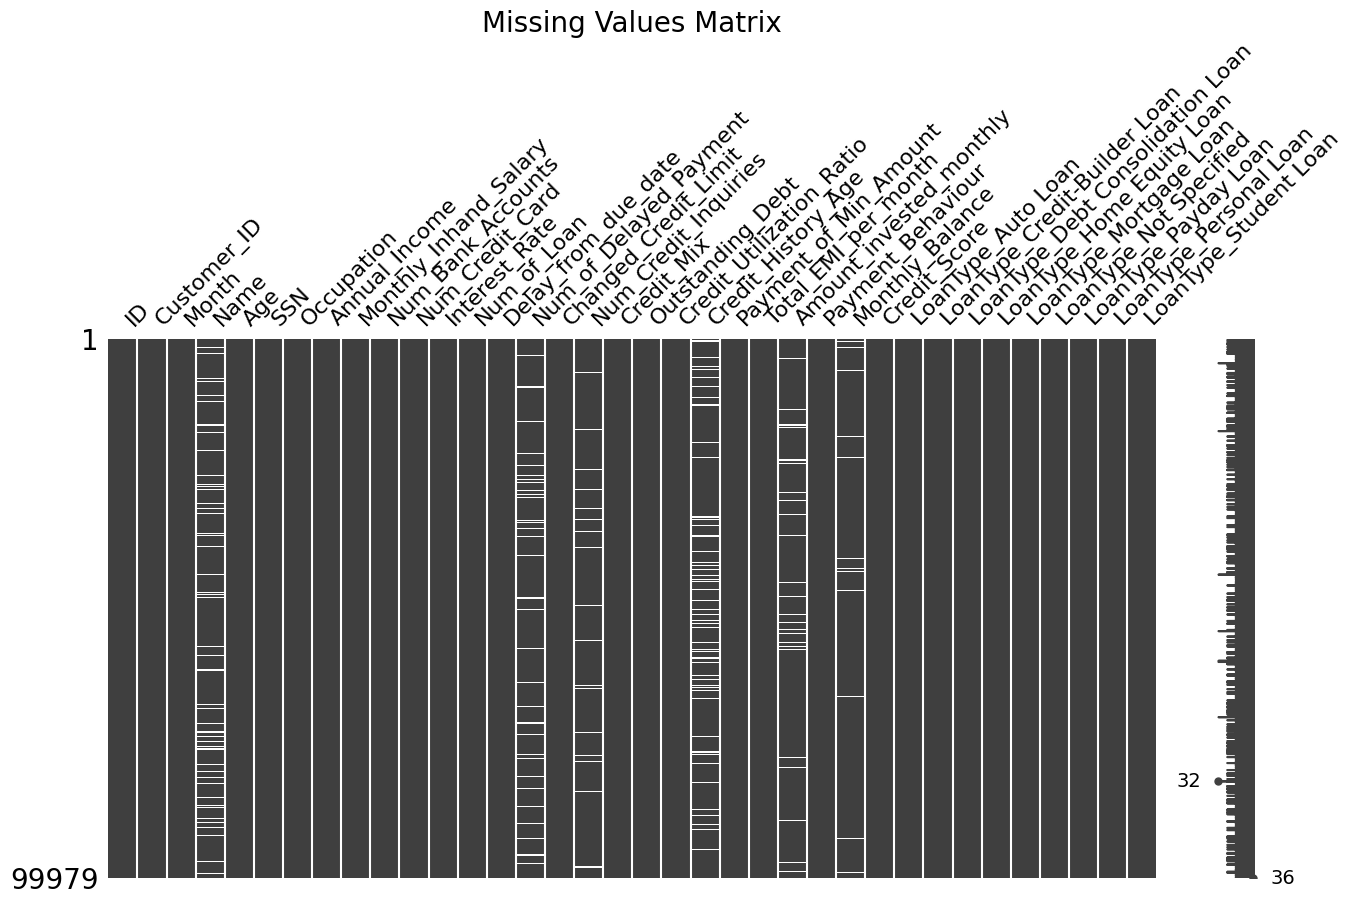

In [48]:
msno.matrix(df, figsize=(15, 7))
plt.title('Missing Values Matrix', fontsize=20)
plt.show()

## 4.7 Num_of_Delayed_Payment


In [49]:
print(df['Num_of_Delayed_Payment'].describe())

count     92977
unique      749
top          19
freq       5327
Name: Num_of_Delayed_Payment, dtype: object


In [50]:
non_numeric_delays = df[pd.to_numeric(df['Num_of_Delayed_Payment'], errors='coerce').isna()]['Num_of_Delayed_Payment'].unique()
print(f"Unique non-numeric values in 'Num_of_Delayed_Payment': {non_numeric_delays}")

Unique non-numeric values in 'Num_of_Delayed_Payment': [nan '8_' '3_' '2_' '13_' '14_' '12_' '22_' '4_' '11_' '21_' '10_' '183_'
 '9_' '19_' '24_' '17_' '23_' '20_' '6_' '1_' '16_' '15_' '26_' '18_' '5_'
 '25_' '7_' '0_' '2569_' '27_' '663_' '-2_' '28_' '-1_' '1323_' '2794_'
 '2219_' '758_' '-3_' '848_' '2237_' '3097_' '2566_' '3840_' '2278_'
 '1087_' '1295_' '3861_' '2142_' '1473_' '3920_']


In [51]:
df["Num_of_Delayed_Payment"] = (df["Num_of_Delayed_Payment"].astype(str).str.replace("_", "", regex=False))
df["Num_of_Delayed_Payment"] = pd.to_numeric(df["Num_of_Delayed_Payment"], errors='coerce')
df.loc[df['Num_of_Delayed_Payment'] < 0, 'Num_of_Delayed_Payment'] = np.nan
df['Num_of_Delayed_Payment'] = df.groupby('Customer_ID')['Num_of_Delayed_Payment'].transform(lambda x: x.ffill().bfill())

In [52]:
print(f"{df['Num_of_Delayed_Payment'].isnull().sum()}")

0


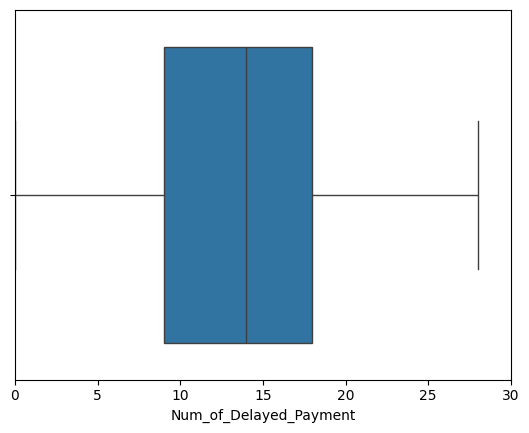

In [53]:
sns.boxplot(x=df["Num_of_Delayed_Payment"])
plt.xlim(0, 30)
plt.show()

In [54]:
weird_delays = df[df['Num_of_Delayed_Payment'] >100]
print(f"{len(weird_delays)}")

772


In [55]:
df.loc[df['Num_of_Delayed_Payment'] > 100, 'Num_of_Delayed_Payment'] = np.nan
df['Num_of_Delayed_Payment'] = df.groupby('Customer_ID')['Num_of_Delayed_Payment'].transform(lambda x: x.ffill().bfill())
print(f"{df['Num_of_Delayed_Payment'].isnull().sum()}")

0


### 4.8 Delay_from_due_date


In [56]:
print(df['Delay_from_due_date'].describe())

count    99979.000000
mean        21.070315
std         14.860719
min         -5.000000
25%         10.000000
50%         18.000000
75%         28.000000
max         67.000000
Name: Delay_from_due_date, dtype: float64


In [57]:
non_numeric_delays = df[pd.to_numeric(df['Delay_from_due_date'], errors='coerce').isna()]['Delay_from_due_date'].unique()
print(f"Unique non-numeric values in 'Delay_from_due_date': {non_numeric_delays}")

Unique non-numeric values in 'Delay_from_due_date': []


In [58]:
df["Delay_from_due_date"] = pd.to_numeric(df["Delay_from_due_date"], errors='coerce')

In [59]:
df.loc[df['Delay_from_due_date'] < 0, 'Delay_from_due_date'] = np.nan

In [60]:
print(f"{df['Delay_from_due_date'].isnull().sum()}")

591


In [61]:
df.dropna(subset=['Delay_from_due_date'], inplace=True)

### 4.9 Annual_Income


In [62]:
df['Annual_Income'] = df['Annual_Income'].astype(str).str.replace(r'[^\d.]', '', regex=True)
df['Annual_Income'] = pd.to_numeric(df['Annual_Income'], errors='coerce')

print(df['Annual_Income'].describe())

count    9.938800e+04
mean     1.761320e+05
std      1.428861e+06
min      7.005930e+03
25%      1.942681e+04
50%      3.748298e+04
75%      7.261755e+04
max      2.419806e+07
Name: Annual_Income, dtype: float64


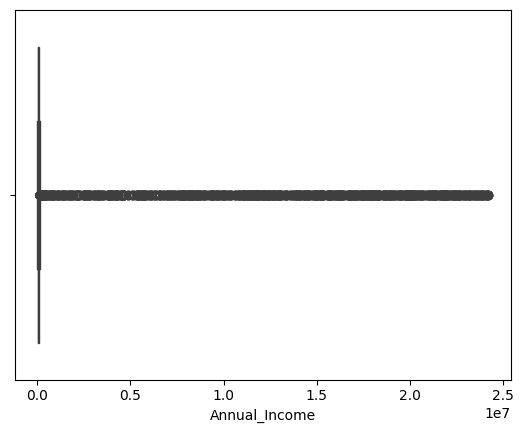

In [63]:
sns.boxplot(x=df['Annual_Income'])
plt.show()

In [64]:
q99 = df['Annual_Income'].quantile(0.99)
print(f"99th percentile: {q99:.2f}")
weird_income = df[df['Annual_Income'] > q99]
print(f"Rows above 99th pct: {len(weird_income)}")

99th percentile: 179987.28
Rows above 99th pct: 991


In [65]:
df.loc[df['Annual_Income'] > df['Annual_Income'].quantile(0.99), 'Annual_Income'] = np.nan
df['Annual_Income'] = df.groupby('Customer_ID')['Annual_Income'].transform(lambda x: x.ffill().bfill())

print(df['Annual_Income'].describe())
print(f"{df['Annual_Income'].isnull().sum()}")

count     99388.000000
mean      50390.856806
std       38218.675263
min        7005.930000
25%       19300.340000
50%       36964.080000
75%       71554.680000
max      179987.280000
Name: Annual_Income, dtype: float64
0


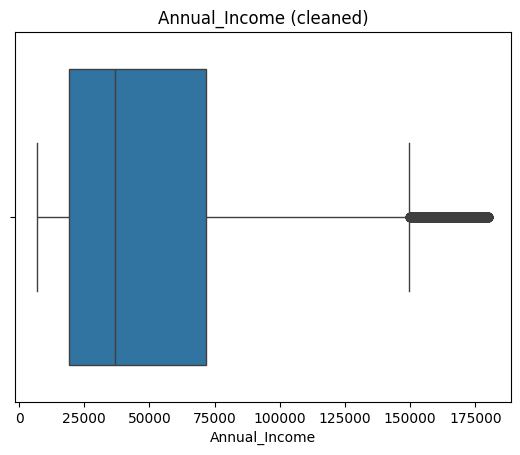

In [66]:
sns.boxplot(x=df['Annual_Income'])
plt.title('Annual_Income (cleaned)')
plt.show()

### 4.10 Occupation


In [67]:
print(df['Occupation'].value_counts())

Occupation
_______          7007
Lawyer           6532
Engineer         6313
Architect        6313
Mechanic         6255
Scientist        6249
Accountant       6227
Developer        6193
Media_Manager    6191
Teacher          6187
Entrepreneur     6139
Doctor           6057
Journalist       6043
Manager          5936
Musician         5878
Writer           5868
Name: count, dtype: int64


In [68]:
df['Occupation'] = df['Occupation'].replace('_______', np.nan)
df['Occupation'] = df.groupby('Customer_ID')['Occupation'].transform(lambda x: x.ffill().bfill())

print(f"{df['Occupation'].isnull().sum()}")
print(df['Occupation'].value_counts())

0
Occupation
Lawyer           7048
Engineer         6820
Architect        6778
Mechanic         6737
Accountant       6698
Scientist        6692
Developer        6675
Media_Manager    6673
Teacher          6642
Entrepreneur     6609
Doctor           6537
Journalist       6490
Manager          6393
Musician         6313
Writer           6283
Name: count, dtype: int64


### 4.11 Changed_Credit_Limit


In [69]:
df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].astype(str).str.replace(r'[^\d.\-]', '', regex=True)
df['Changed_Credit_Limit'] = pd.to_numeric(df['Changed_Credit_Limit'], errors='coerce')

print(df['Changed_Credit_Limit'].describe())
print(f"{df['Changed_Credit_Limit'].isnull().sum()}")

count    97304.000000
mean        10.415462
std          6.795145
min         -6.490000
25%          5.350000
50%          9.430000
75%         14.920000
max         36.970000
Name: Changed_Credit_Limit, dtype: float64
2084


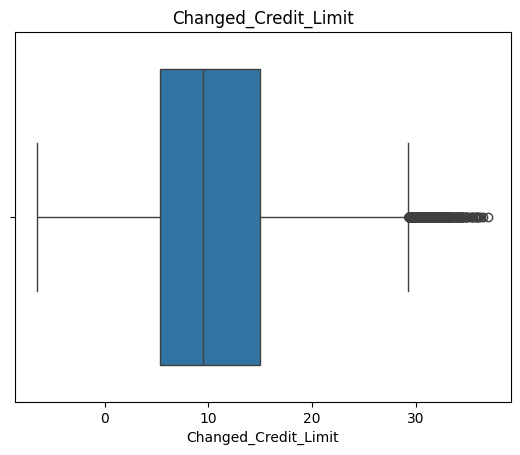

In [70]:
sns.boxplot(x=df['Changed_Credit_Limit'])
plt.title('Changed_Credit_Limit')
plt.show()

In [71]:
df['Changed_Credit_Limit'] = df.groupby('Customer_ID')['Changed_Credit_Limit'].transform(lambda x: x.ffill().bfill())
print(f"{df['Changed_Credit_Limit'].isnull().sum()}")

0


### 4.12 Num_Credit_Inquiries


count    97437.000000
mean        27.747909
std        193.133954
min          0.000000
25%          3.000000
50%          6.000000
75%          9.000000
max       2597.000000
Name: Num_Credit_Inquiries, dtype: float64


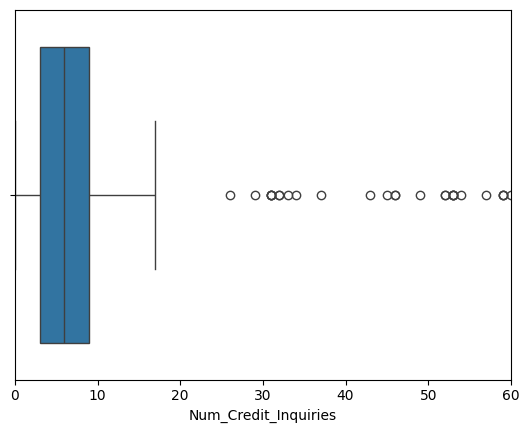

In [72]:
print(df['Num_Credit_Inquiries'].describe())
sns.boxplot(x=df['Num_Credit_Inquiries'])
plt.xlim(0, 60)
plt.show()

In [73]:
weird_inquiries = df[df['Num_Credit_Inquiries'] > 50]
print(f"{len(weird_inquiries)}")

1622


In [74]:
df.loc[df['Num_Credit_Inquiries'] > 50, 'Num_Credit_Inquiries'] = np.nan
df['Num_Credit_Inquiries'] = df.groupby('Customer_ID')['Num_Credit_Inquiries'].transform(lambda x: x.ffill().bfill())

print(df['Num_Credit_Inquiries'].describe())
print(f"{df['Num_Credit_Inquiries'].isnull().sum()}")

count    99388.000000
mean         5.795780
std          3.882305
min          0.000000
25%          3.000000
50%          5.000000
75%          8.000000
max         49.000000
Name: Num_Credit_Inquiries, dtype: float64
0


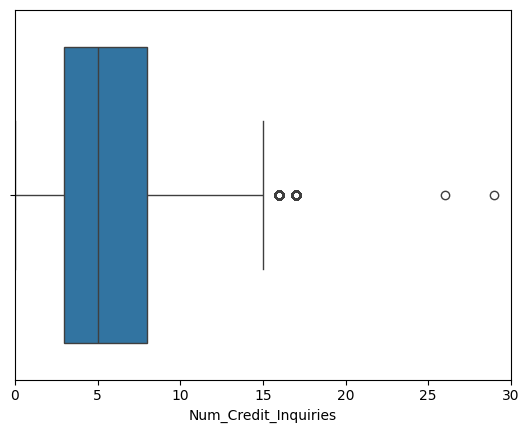

In [75]:
sns.boxplot(x=df['Num_Credit_Inquiries'])
plt.xlim(0, 30)
plt.show()

### 4.13 Outstanding_Debt


In [76]:
df['Outstanding_Debt'] = df['Outstanding_Debt'].astype(str).str.replace(r'[^\d.]', '', regex=True)
df['Outstanding_Debt'] = pd.to_numeric(df['Outstanding_Debt'], errors='coerce')

print(df['Outstanding_Debt'].describe())
print(f"{df['Outstanding_Debt'].isnull().sum()}")

count    99388.000000
mean      1430.813472
std       1156.668738
min          0.230000
25%        568.670000
50%       1169.610000
75%       1958.360000
max       4998.070000
Name: Outstanding_Debt, dtype: float64
0


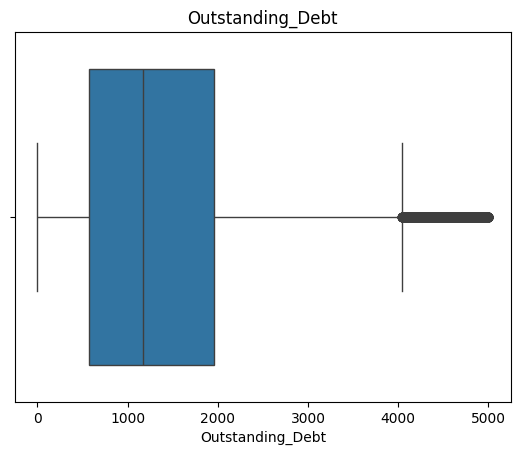

In [77]:
sns.boxplot(x=df['Outstanding_Debt'])
plt.title('Outstanding_Debt')
plt.show()

### 4.14 Credit_Utilization_Ratio


In [78]:
print(df['Credit_Utilization_Ratio'].describe())
print(f"{df['Credit_Utilization_Ratio'].isnull().sum()}")

count    99388.000000
mean        32.282709
std          5.116250
min         20.000000
25%         28.051854
50%         32.303850
75%         36.495621
max         50.000000
Name: Credit_Utilization_Ratio, dtype: float64
0


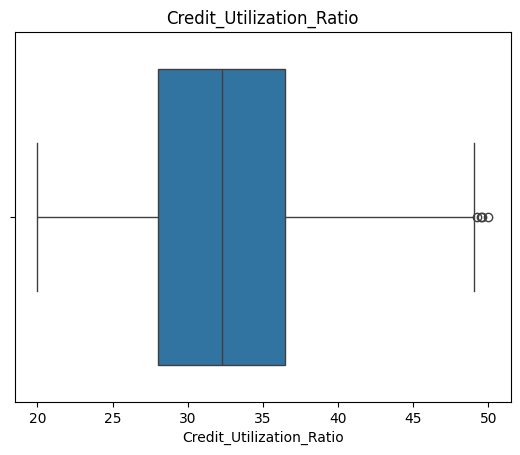

In [79]:
sns.boxplot(x=df['Credit_Utilization_Ratio'])
plt.title('Credit_Utilization_Ratio')
plt.show()

### 4.15 Credit_History_Age


In [80]:
print(df['Credit_History_Age'].describe())
print(df['Credit_History_Age'].value_counts().head(10))

count                      90424
unique                       404
top       15 Years and 11 Months
freq                         443
Name: Credit_History_Age, dtype: object
Credit_History_Age
15 Years and 11 Months    443
19 Years and 4 Months     443
19 Years and 5 Months     442
17 Years and 11 Months    440
19 Years and 3 Months     438
17 Years and 9 Months     437
17 Years and 10 Months    432
15 Years and 10 Months    431
15 Years and 9 Months     430
18 Years and 3 Months     426
Name: count, dtype: int64


In [81]:
import re

def parse_credit_history_age(value):
    if pd.isna(value):
        return np.nan
    match = re.match(r'(\d+)\s*Years?\s*and\s*(\d+)\s*Months?', str(value))
    if match:
        years = int(match.group(1))
        months = int(match.group(2))
        return years * 12 + months
    return np.nan

df['Credit_History_Age'] = df['Credit_History_Age'].apply(parse_credit_history_age)

print(df['Credit_History_Age'].describe())
print(f"{df['Credit_History_Age'].isnull().sum()}")

count    90424.000000
mean       220.771620
std         99.772218
min          1.000000
25%        144.000000
50%        219.000000
75%        301.000000
max        404.000000
Name: Credit_History_Age, dtype: float64
8964


In [82]:
df['Credit_History_Age'] = df.groupby('Customer_ID')['Credit_History_Age'].transform(lambda x: x.ffill().bfill())
print(f"{df['Credit_History_Age'].isnull().sum()}")

0


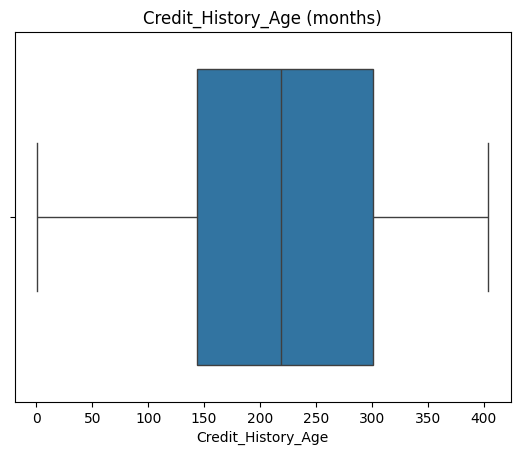

In [83]:
sns.boxplot(x=df['Credit_History_Age'])
plt.title('Credit_History_Age (months)')
plt.show()

### 4.16 Credit_Mix


In [84]:
print(df['Credit_Mix'].value_counts())

Credit_Mix
Standard    36479
Good        23841
_           20079
Bad         18989
Name: count, dtype: int64


In [85]:
df['Credit_Mix'] = df['Credit_Mix'].replace('_', np.nan)
df['Credit_Mix'] = df.groupby('Customer_ID')['Credit_Mix'].transform(lambda x: x.ffill().bfill())

print(df['Credit_Mix'].value_counts())
print(f"{df['Credit_Mix'].isnull().sum()}")

/tmp/ipykernel_1734/2642109608.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Credit_Mix'] = df.groupby('Customer_ID')['Credit_Mix'].transform(lambda x: x.ffill().bfill())


Credit_Mix
Standard    45848
Good        29771
Bad         23768
Name: count, dtype: int64
1


In [86]:
credit_mix_map = {'Bad': 0, 'Standard': 1, 'Good': 2}
df['Credit_Mix'] = df['Credit_Mix'].map(credit_mix_map)
print(df['Credit_Mix'].value_counts())

Credit_Mix
1.0    45848
2.0    29771
0.0    23768
Name: count, dtype: int64


### 4.17 Payment_of_Min_Amount


In [87]:
print(df['Payment_of_Min_Amount'].value_counts())

Payment_of_Min_Amount
Yes    52326
No     35118
NM     11944
Name: count, dtype: int64


In [88]:
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].replace('NM', np.nan)
df['Payment_of_Min_Amount'] = df.groupby('Customer_ID')['Payment_of_Min_Amount'].transform(lambda x: x.ffill().bfill())

print(df['Payment_of_Min_Amount'].value_counts())
print(f"{df['Payment_of_Min_Amount'].isnull().sum()}")

Payment_of_Min_Amount
Yes    59432
No     39956
Name: count, dtype: int64
0


In [89]:
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].map({'No': 0, 'Yes': 1})
print(df['Payment_of_Min_Amount'].value_counts())

Payment_of_Min_Amount
1    59432
0    39956
Name: count, dtype: int64


### 4.18 Total_EMI_per_month


count    99388.000000
mean      1404.185083
std       8307.820851
min          0.000000
25%         30.415464
50%         69.285581
75%        161.224249
max      82331.000000
Name: Total_EMI_per_month, dtype: float64


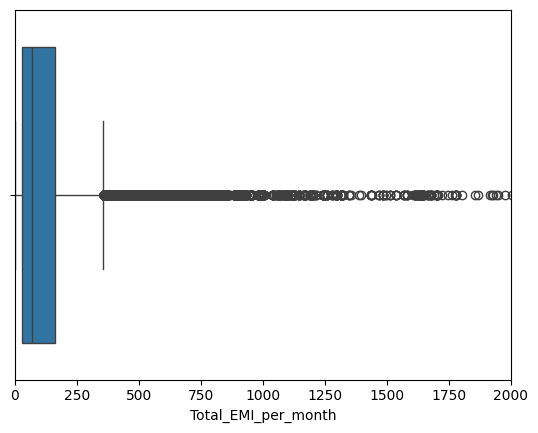

In [90]:
print(df['Total_EMI_per_month'].describe())
sns.boxplot(x=df['Total_EMI_per_month'])
plt.xlim(0, 2000)
plt.show()

In [91]:
weird_emi = df[df['Total_EMI_per_month'] > 400]
print(f"{len(weird_emi)}")

5565


In [92]:
upper_bound_emi = df['Total_EMI_per_month'].quantile(0.99)
df.loc[df['Total_EMI_per_month'] > upper_bound_emi, 'Total_EMI_per_month'] = upper_bound_emi

print(df['Total_EMI_per_month'].describe())
print(f"Number of values capped: {(df['Total_EMI_per_month'] == upper_bound_emi).sum()}")

count    99388.000000
mean      1274.578110
std       7250.865579
min          0.000000
25%         30.415464
50%         69.285581
75%        161.224249
max      56080.630000
Name: Total_EMI_per_month, dtype: float64
Number of values capped: 994


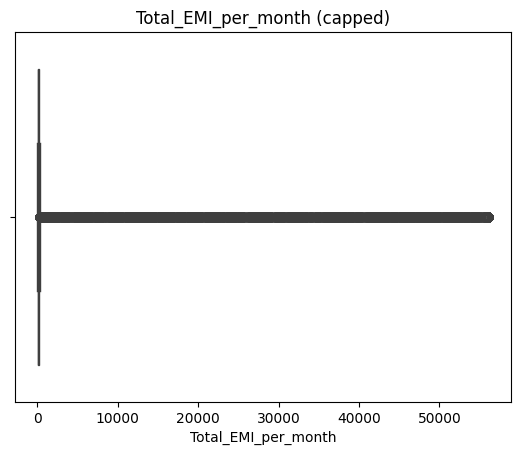

In [93]:
sns.boxplot(x=df['Total_EMI_per_month'])
plt.title('Total_EMI_per_month (capped)')
plt.show()

### 4.19 Amount_invested_monthly


In [94]:
df['Amount_invested_monthly'] = df['Amount_invested_monthly'].astype(str).str.replace(r'[^\d.]', '', regex=True)
df['Amount_invested_monthly'] = pd.to_numeric(df['Amount_invested_monthly'], errors='coerce')

print(df['Amount_invested_monthly'].describe())
print(f"{df['Amount_invested_monthly'].isnull().sum()}")

count    94933.000000
mean       637.079542
std       2043.476268
min          0.000000
25%         74.414447
50%        135.660315
75%        265.292177
max      10000.000000
Name: Amount_invested_monthly, dtype: float64
4455


In [95]:
df['Amount_invested_monthly'] = df.groupby('Customer_ID')['Amount_invested_monthly'].transform(lambda x: x.ffill().bfill())
print(f"{df['Amount_invested_monthly'].isnull().sum()}")

0


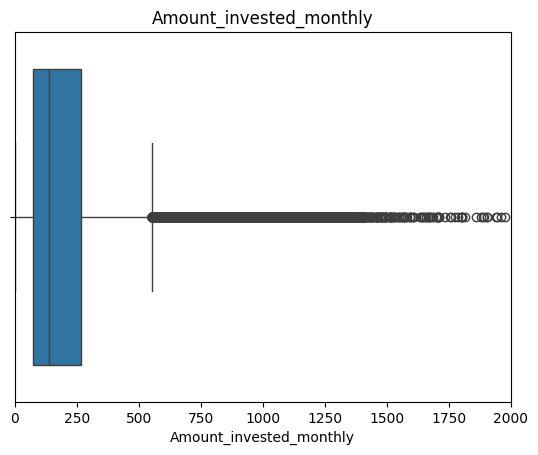

In [96]:
sns.boxplot(x=df['Amount_invested_monthly'])
plt.xlim(0, 2000)
plt.title('Amount_invested_monthly')
plt.show()

### 4.20 Payment_Behaviour


In [97]:
print(df['Payment_Behaviour'].value_counts())

Payment_Behaviour
Low_spent_Small_value_payments      25391
High_spent_Medium_value_payments    17439
Low_spent_Medium_value_payments     13759
High_spent_Large_value_payments     13610
High_spent_Small_value_payments     11277
Low_spent_Large_value_payments      10361
!@9#%8                               7551
Name: count, dtype: int64


In [98]:
df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', np.nan)
df['Payment_Behaviour'] = df.groupby('Customer_ID')['Payment_Behaviour'].transform(lambda x: x.ffill().bfill())

print(df['Payment_Behaviour'].value_counts())
print(f"{df['Payment_Behaviour'].isnull().sum()}")

Payment_Behaviour
Low_spent_Small_value_payments      27464
High_spent_Medium_value_payments    18906
Low_spent_Medium_value_payments     14896
High_spent_Large_value_payments     14722
High_spent_Small_value_payments     12175
Low_spent_Large_value_payments      11225
Name: count, dtype: int64
0


In [99]:
payment_behaviour_dummies = pd.get_dummies(df['Payment_Behaviour'], prefix='PayBeh')
df = pd.concat([df.drop(columns=['Payment_Behaviour']), payment_behaviour_dummies], axis=1)
display(df.head())

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_Score,LoanType_Auto Loan,LoanType_Credit-Builder Loan,LoanType_Debt Consolidation Loan,LoanType_Home Equity Loan,LoanType_Mortgage Loan,LoanType_Not Specified,LoanType_Payday Loan,LoanType_Personal Loan,LoanType_Student Loan,PayBeh_High_spent_Large_value_payments,PayBeh_High_spent_Medium_value_payments,PayBeh_High_spent_Small_value_payments,PayBeh_Low_spent_Large_value_payments,PayBeh_Low_spent_Medium_value_payments,PayBeh_Low_spent_Small_value_payments
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,3.0,7.0,11.27,4.0,2.0,809.98,26.822620,265.0,0,49.574949,80.415295,312.49408867943663,Good,1,1,0,1,0,0,0,1,0,False,False,True,False,False,False
2,0x1604,CUS_0xd40,March,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,3.0,7.0,11.27,4.0,2.0,809.98,28.609352,267.0,0,49.574949,81.699521,331.2098628537912,Good,1,1,0,1,0,0,0,1,0,False,False,False,False,True,False
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,5.0,4.0,6.27,4.0,2.0,809.98,31.377862,268.0,0,49.574949,199.458074,223.45130972736786,Good,1,1,0,1,0,0,0,1,0,False,False,False,False,False,True
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,6.0,4.0,11.27,4.0,2.0,809.98,24.797347,269.0,0,49.574949,41.420153,341.48923103222177,Good,1,1,0,1,0,0,0,1,0,False,True,False,False,False,False
5,0x1607,CUS_0xd40,June,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,8.0,4.0,9.27,4.0,2.0,809.98,27.262259,270.0,0,49.574949,62.430172,340.4792117872438,Good,1,1,0,1,0,0,0,1,0,False,True,False,False,False,False


### 4.21 Monthly_Balance


In [100]:
df['Monthly_Balance'] = df['Monthly_Balance'].astype(str).str.replace(r'[^\d.\-]', '', regex=True)
df['Monthly_Balance'] = pd.to_numeric(df['Monthly_Balance'], errors='coerce')

df.loc[df['Monthly_Balance'] < 0, 'Monthly_Balance'] = np.nan

print(df['Monthly_Balance'].describe())
print(f"{df['Monthly_Balance'].isnull().sum()}")

count    98187.000000
mean       401.878534
std        213.298308
min          0.007760
25%        269.985619
50%        336.348173
75%        469.267799
max       1602.040519
Name: Monthly_Balance, dtype: float64
1201


In [101]:
df['Monthly_Balance'] = df.groupby('Customer_ID')['Monthly_Balance'].transform(lambda x: x.ffill().bfill())
print(f"{df['Monthly_Balance'].isnull().sum()}")

0


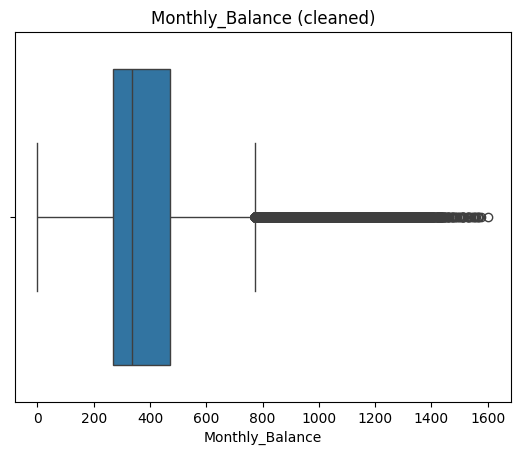

In [102]:
sns.boxplot(x=df['Monthly_Balance'])
plt.title('Monthly_Balance (cleaned)')
plt.show()

### 4.22 Credit_Score (zmienna docelowa)


In [103]:
print(df['Credit_Score'].value_counts())

Credit_Score
Standard    52955
Poor        28942
Good        17491
Name: count, dtype: int64


In [104]:
credit_score_map = {'Poor': 0, 'Standard': 1, 'Good': 2}
df['Credit_Score'] = df['Credit_Score'].map(credit_score_map)
print(df['Credit_Score'].value_counts())

Credit_Score
1    52955
0    28942
2    17491
Name: count, dtype: int64


### 5. Usuń kolumny nieinformacyjne


In [105]:
df = df.drop(columns=['ID', 'Name', 'SSN', 'Month'], errors='ignore')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99388 entries, 0 to 99999
Data columns (total 37 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Customer_ID                              99388 non-null  object 
 1   Age                                      99388 non-null  float64
 2   Occupation                               99388 non-null  object 
 3   Annual_Income                            99388 non-null  float64
 4   Monthly_Inhand_Salary                    99388 non-null  float64
 5   Num_Bank_Accounts                        99388 non-null  float64
 6   Num_Credit_Card                          99388 non-null  float64
 7   Interest_Rate                            99388 non-null  float64
 8   Num_of_Loan                              99388 non-null  float64
 9   Delay_from_due_date                      99388 non-null  float64
 10  Num_of_Delayed_Payment                   99388 non-

### 6. Ostateczna kontrola brakujących wartości


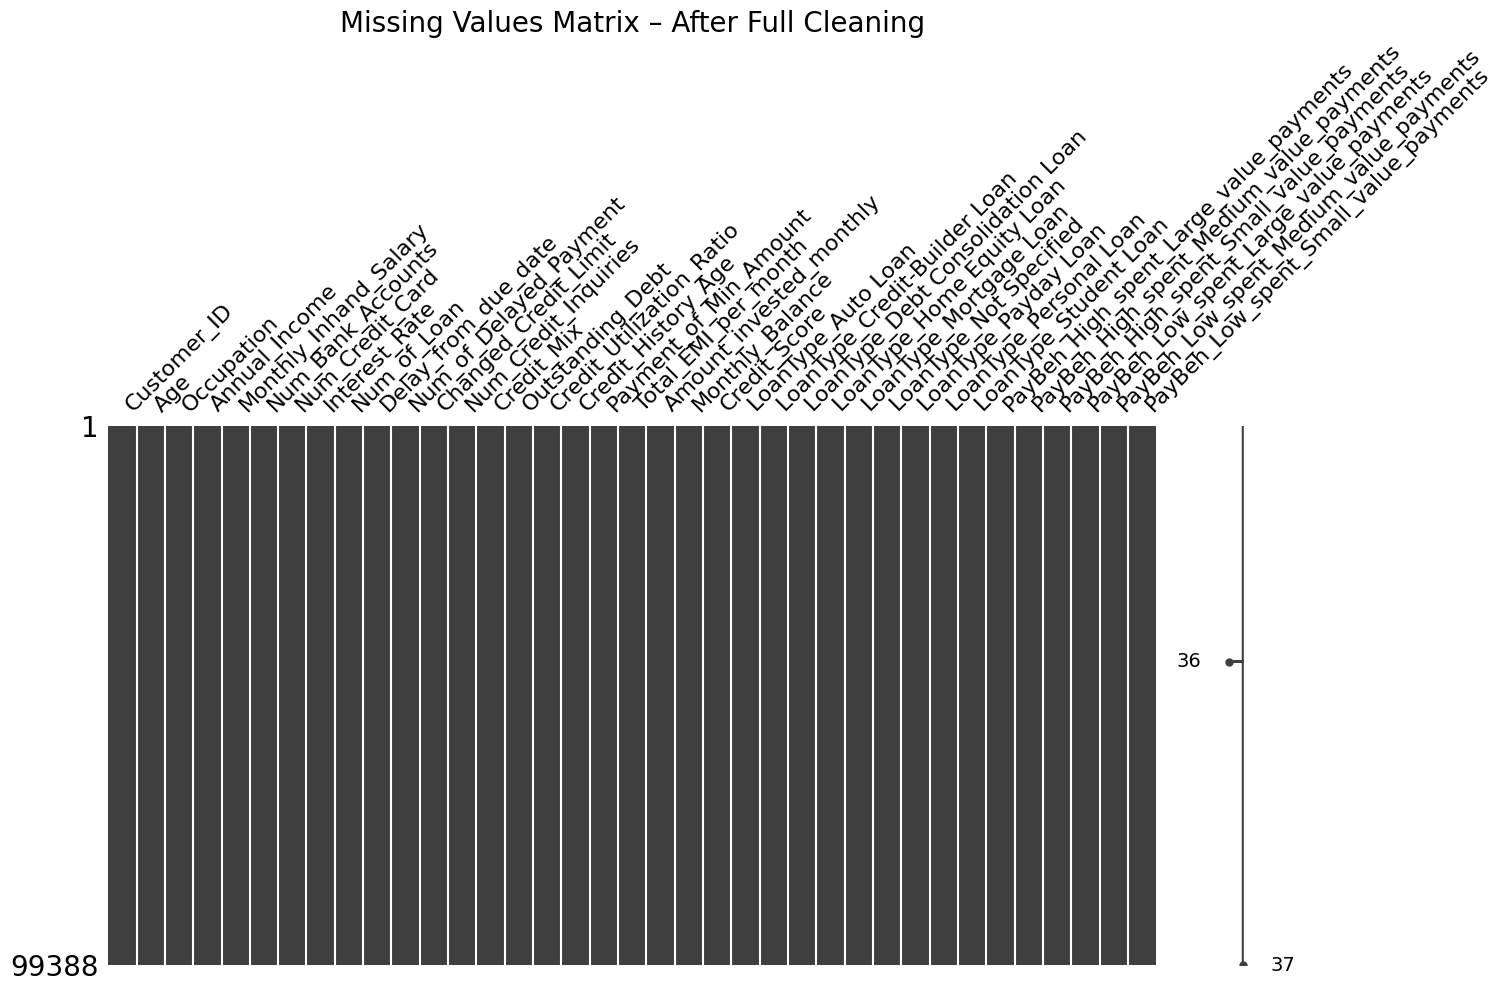

In [106]:
msno.matrix(df, figsize=(15, 7))
plt.title('Missing Values Matrix – After Full Cleaning', fontsize=20)
plt.show()

In [107]:
missing_summary = df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)
print(missing_summary)

Credit_Mix    1
dtype: int64


## 7.1 EDA – Rozkłady cech numerycznych


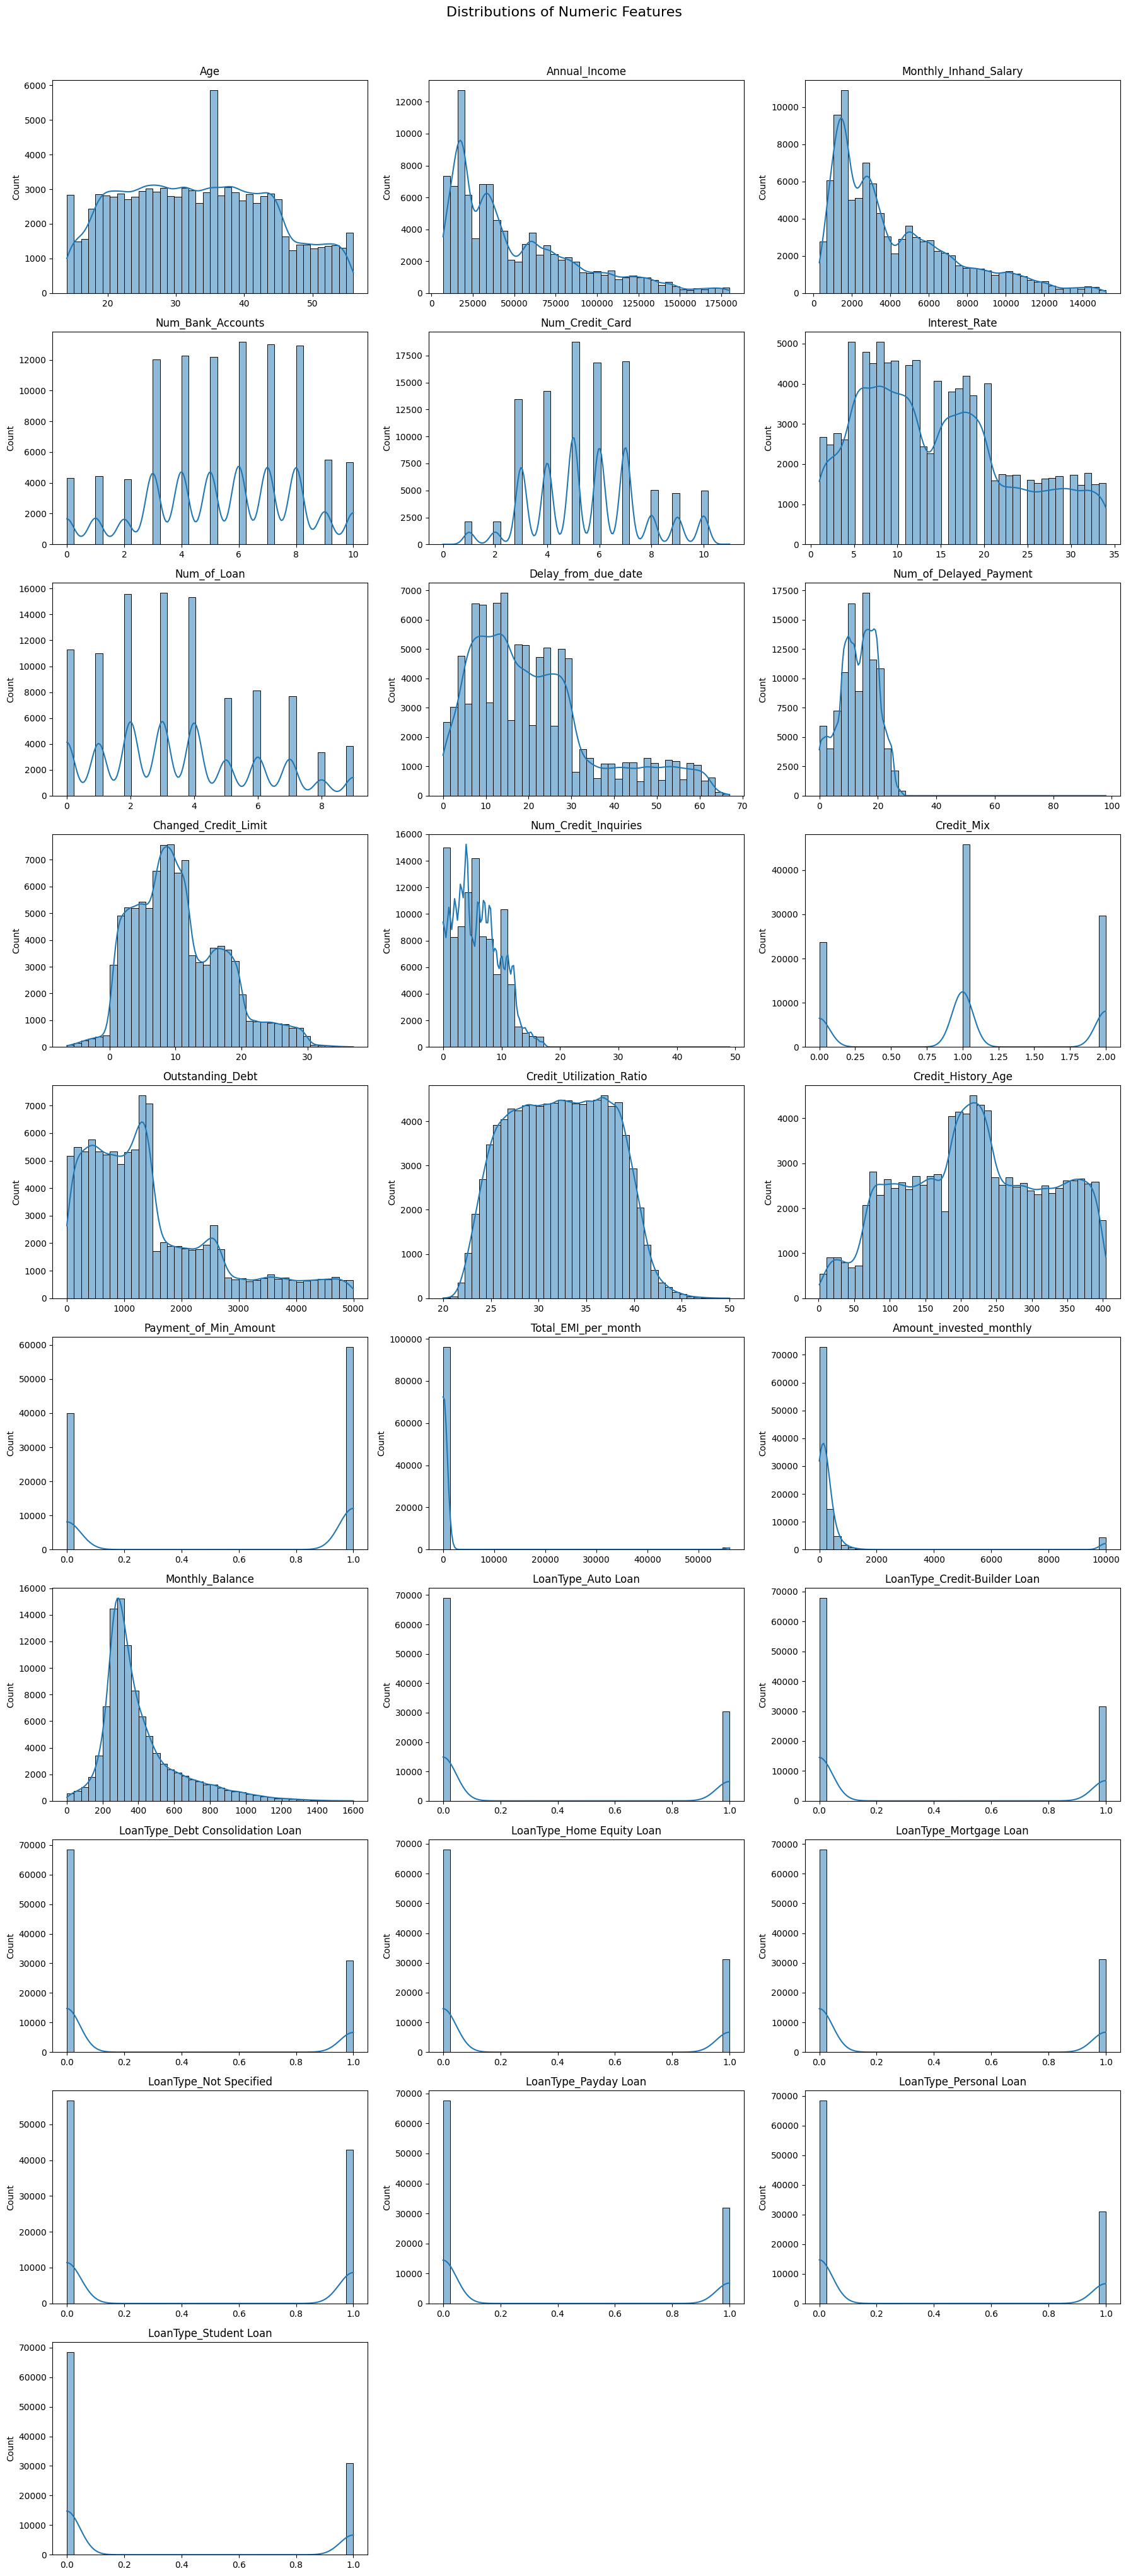

In [108]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'Credit_Score']

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), ax=axes[i], kde=True, bins=40)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.suptitle('Distributions of Numeric Features', y=1.02, fontsize=16)
plt.show()

## 7.2 EDA – Mapa ciepła korelacji


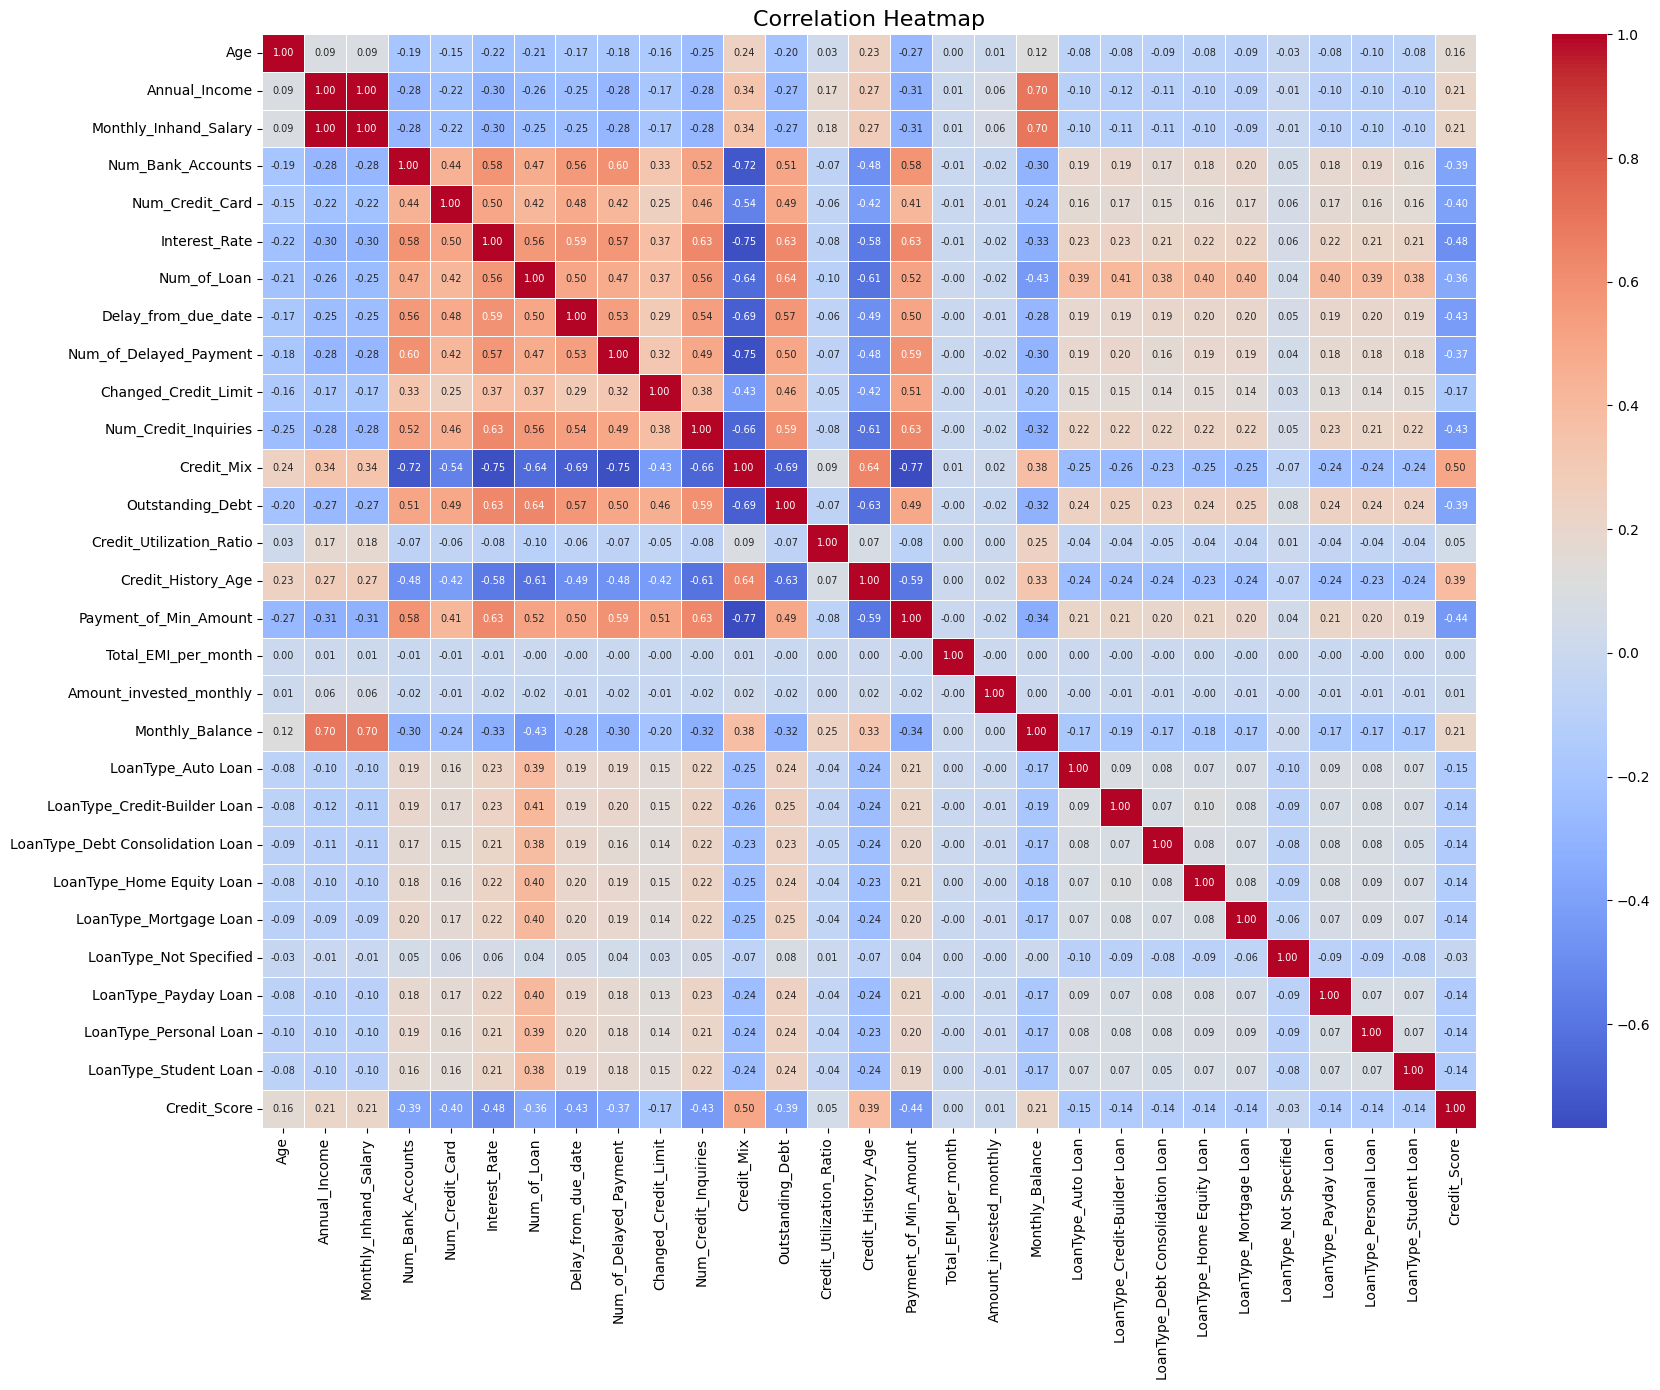

In [109]:
corr = df[numeric_cols + ['Credit_Score']].corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

## 7.3 EDA – Key features vs Credit_Score


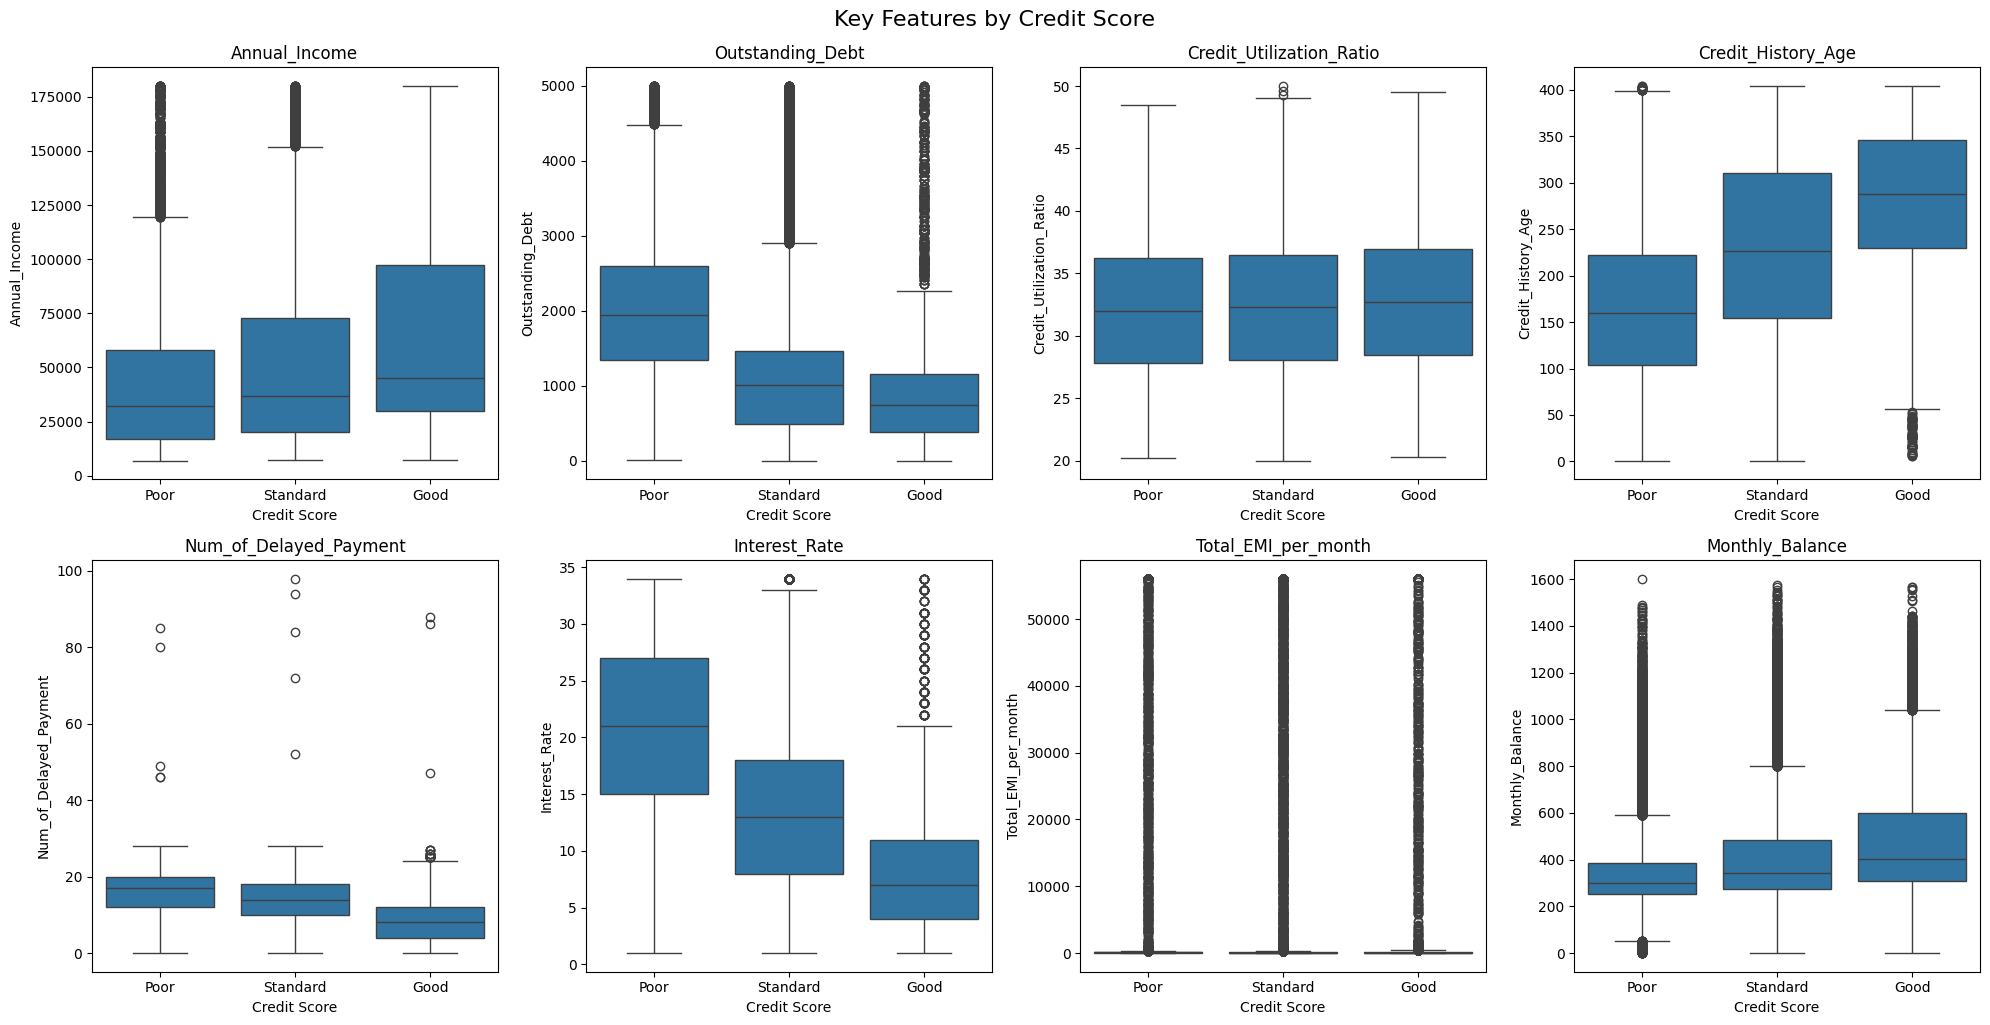

In [110]:
key_features = [
    'Annual_Income', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
    'Credit_History_Age', 'Num_of_Delayed_Payment', 'Interest_Rate',
    'Total_EMI_per_month', 'Monthly_Balance'
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

score_labels = {0: 'Poor', 1: 'Standard', 2: 'Good'}
df['Credit_Score_Label'] = df['Credit_Score'].map(score_labels)

for i, col in enumerate(key_features):
    sns.boxplot(x='Credit_Score_Label', y=col, data=df,
                order=['Poor', 'Standard', 'Good'], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Credit Score')

plt.tight_layout()
plt.suptitle('Key Features by Credit Score', y=1.02, fontsize=16)
plt.show()

df = df.drop(columns=['Credit_Score_Label'])

## 7.4 EDA – Categorical features vs Credit_Score


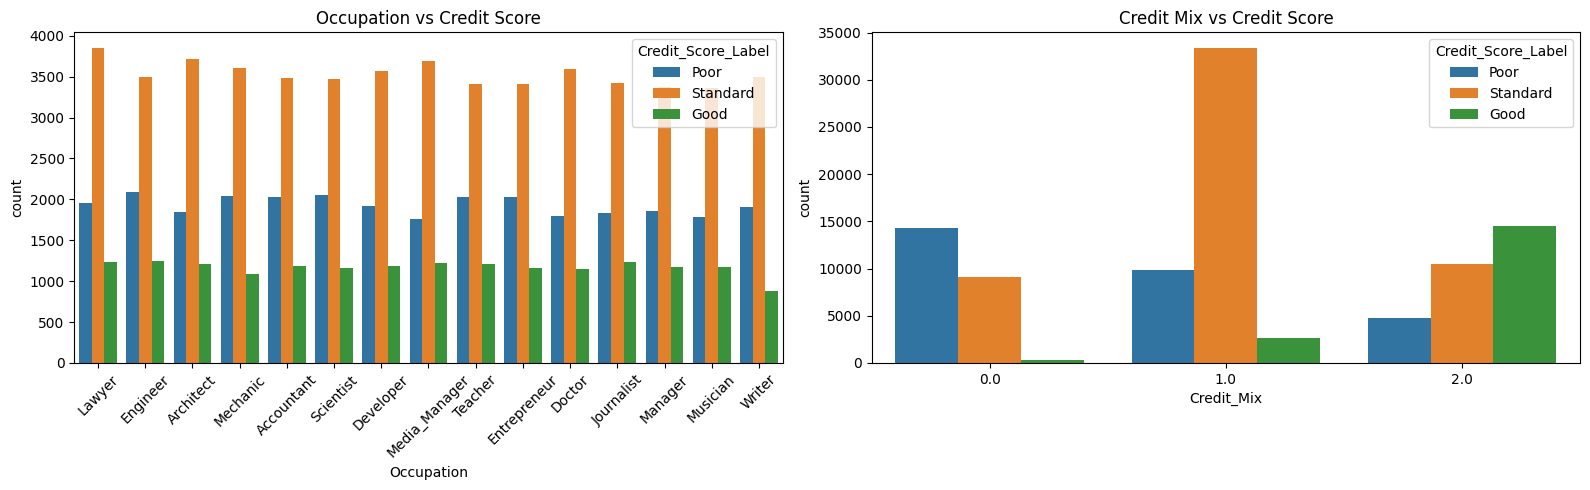

In [111]:
df['Credit_Score_Label'] = df['Credit_Score'].map({0: 'Poor', 1: 'Standard', 2: 'Good'})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

occ_order = df['Occupation'].value_counts().index
sns.countplot(data=df, x='Occupation', hue='Credit_Score_Label',
              order=occ_order, ax=axes[0],
              hue_order=['Poor', 'Standard', 'Good'])
axes[0].set_title('Occupation vs Credit Score')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='Credit_Mix', hue='Credit_Score_Label',
              order=sorted(df['Credit_Mix'].dropna().unique()),
              ax=axes[1], hue_order=['Poor', 'Standard', 'Good'])
axes[1].set_title('Credit Mix vs Credit Score')

plt.tight_layout()
plt.show()

df = df.drop(columns=['Credit_Score_Label'])

## 8. Ostateczne podsumowanie ramki danych


In [112]:
print(f"Final shape: {df.shape}")
df.info()

Final shape: (99388, 37)
<class 'pandas.core.frame.DataFrame'>
Index: 99388 entries, 0 to 99999
Data columns (total 37 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Customer_ID                              99388 non-null  object 
 1   Age                                      99388 non-null  float64
 2   Occupation                               99388 non-null  object 
 3   Annual_Income                            99388 non-null  float64
 4   Monthly_Inhand_Salary                    99388 non-null  float64
 5   Num_Bank_Accounts                        99388 non-null  float64
 6   Num_Credit_Card                          99388 non-null  float64
 7   Interest_Rate                            99388 non-null  float64
 8   Num_of_Loan                              99388 non-null  float64
 9   Delay_from_due_date                      99388 non-null  float64
 10  Num_of_Delayed_Payment    

In [113]:
display(df.head(10))

,Customer_ID,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_Score,LoanType_Auto Loan,LoanType_Credit-Builder Loan,LoanType_Debt Consolidation Loan,LoanType_Home Equity Loan,LoanType_Mortgage Loan,LoanType_Not Specified,LoanType_Payday Loan,LoanType_Personal Loan,LoanType_Student Loan,PayBeh_High_spent_Large_value_payments,PayBeh_High_spent_Medium_value_payments,PayBeh_High_spent_Small_value_payments,PayBeh_Low_spent_Large_value_payments,PayBeh_Low_spent_Medium_value_payments,PayBeh_Low_spent_Small_value_payments
0,CUS_0xd40,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,3.0,7.0,11.27,4.0,2.0,809.98,26.822620,265.0,0,49.574949,80.415295,312.494089,2,1,1,0,1,0,0,0,1,0,False,False,True,False,False,False
2,CUS_0xd40,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,3.0,7.0,11.27,4.0,2.0,809.98,28.609352,267.0,0,49.574949,81.699521,331.209863,2,1,1,0,1,0,0,0,1,0,False,False,False,False,True,False
3,CUS_0xd40,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,5.0,4.0,6.27,4.0,2.0,809.98,31.377862,268.0,0,49.574949,199.458074,223.451310,2,1,1,0,1,0,0,0,1,0,False,False,False,False,False,True
4,CUS_0xd40,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,6.0,4.0,11.27,4.0,2.0,809.98,24.797347,269.0,0,49.574949,41.420153,341.489231,2,1,1,0,1,0,0,0,1,0,False,True,False,False,False,False
5,CUS_0xd40,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,8.0,4.0,9.27,4.0,2.0,809.98,27.262259,270.0,0,49.574949,62.430172,340.479212,2,1,1,0,1,0,0,0,1,0,False,True,False,False,False,False
6,CUS_0xd40,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,3.0,8.0,11.27,4.0,2.0,809.98,22.537593,271.0,0,49.574949,178.344067,244.565317,2,1,1,0,1,0,0,0,1,0,False,False,False,False,False,True
7,CUS_0xd40,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,3.0,6.0,11.27,4.0,2.0,809.98,23.933795,271.0,0,49.574949,24.785217,358.124168,1,1,1,0,1,0,0,0,1,0,False,True,False,False,False,False
8,CUS_0x21b1,28.0,Teacher,34847.84,3037.986667,2.0,4.0,6.0,1.0,3.0,4.0,5.42,2.0,2.0,605.03,24.464031,319.0,0,18.816215,104.291825,470.690627,1,0,1,0,0,0,0,0,0,0,False,False,False,False,False,True
9,CUS_0x21b1,28.0,Teacher,34847.84,3037.986667,2.0,4.0,6.0,1.0,7.0,1.0,7.42,2.0,2.0,605.03,38.550848,320.0,0,18.816215,40.391238,484.591214,2,0,1,0,0,0,0,0,0,0,True,False,False,False,False,False
10,CUS_0x21b1,28.0,Teacher,34847.84,3037.986667,2.0,4.0,6.0,1.0,3.0,1.0,5.42,2.0,2.0,605.03,33.224951,321.0,0,18.816215,58.515976,466.466476,1,0,1,0,0,0,0,0,0,0,True,False,False,False,False,False


# Trenowanie modelu

### 9. Train-Test Split

In [128]:
from sklearn.model_selection import train_test_split

y = df['Credit_Score']
X = df.drop(columns=['Customer_ID', 'Credit_Score'])

X = pd.get_dummies(X, columns=['Occupation'], drop_first=True)

for col in X.select_dtypes(include='bool').columns:
    X[col] = X[col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [129]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = df.dropna(subset=["Credit_Mix"])

lr = LogisticRegression(
    multi_class="multinomial",
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression accuracy: 0.5536774323372573
              precision    recall  f1-score   support

           0       0.54      0.35      0.43      5789
           1       0.56      0.84      0.67     10591
           2       0.61      0.02      0.04      3498

    accuracy                           0.55     19878
   macro avg       0.57      0.40      0.38     19878
weighted avg       0.56      0.55      0.49     19878

[[2042 3737   10]
 [1665 8887   39]
 [  70 3351   77]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [130]:
from sklearn.ensemble import RandomForestClassifier

y = df["Credit_Score"]
X = df.drop(columns=["Customer_ID", "Credit_Score"])

X = pd.get_dummies(X, columns=["Occupation"], drop_first=True)

for col in X.select_dtypes(include="bool").columns:
    X[col] = X[col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest accuracy: 0.817084213703592
              precision    recall  f1-score   support

           0       0.79      0.87      0.83      5789
           1       0.87      0.78      0.82     10591
           2       0.74      0.82      0.78      3498

    accuracy                           0.82     19878
   macro avg       0.80      0.83      0.81     19878
weighted avg       0.82      0.82      0.82     19878

[[5064  673   52]
 [1340 8295  956]
 [  14  601 2883]]


In [115]:
pip install autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 8.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is stil

### 10. AutoGluon Model Training

In [116]:
import autogluon
from autogluon.tabular import TabularDataset, TabularPredictor

train_data = X_train.copy()
train_data['Credit_Score'] = y_train

predictor = TabularPredictor(label='Credit_Score', path="sciezka45", eval_metric="f1_macro").fit(train_data)

predictor.save('sciezka45/')

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       10.76 GB / 12.67 GB (84.9%)
Disk Space Avail:   71.94 GB / 107.72 GB (66.8%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-art for tabular data. Massively better than 'best' on datasets <100000 samples by using new Tabular Foundation Models (TFMs) meta-learned on https://tabarena.ai: TabPFNv2, TabICL, Mitra, TabDPT, and TabM. Requires a GPU and `pip install au

[1000]	valid_set's multi_logloss: 0.537637	valid_set's f1_macro: 0.767922
[2000]	valid_set's multi_logloss: 0.495154	valid_set's f1_macro: 0.793618
[3000]	valid_set's multi_logloss: 0.479315	valid_set's f1_macro: 0.795172
[4000]	valid_set's multi_logloss: 0.473787	valid_set's f1_macro: 0.796691
[5000]	valid_set's multi_logloss: 0.472062	valid_set's f1_macro: 0.804306
[6000]	valid_set's multi_logloss: 0.475615	valid_set's f1_macro: 0.802885


	0.8063	 = Validation score   (f1_macro)
	146.57s	 = Training   runtime
	7.25s	 = Validation runtime
Fitting model: LightGBM ...
	Fitting with cpus=1, gpus=0, mem=0.1/10.5 GB


[1000]	valid_set's multi_logloss: 0.519445	valid_set's f1_macro: 0.778857
[2000]	valid_set's multi_logloss: 0.491045	valid_set's f1_macro: 0.794456


	0.7977	 = Validation score   (f1_macro)
	65.02s	 = Training   runtime
	1.14s	 = Validation runtime
Fitting model: RandomForestGini ...
	Fitting with cpus=2, gpus=0, mem=1.1/10.5 GB
	0.8084	 = Validation score   (f1_macro)
	73.17s	 = Training   runtime
	0.57s	 = Validation runtime
Fitting model: RandomForestEntr ...
	Fitting with cpus=2, gpus=0, mem=1.1/9.7 GB
	0.8094	 = Validation score   (f1_macro)
	78.67s	 = Training   runtime
	0.31s	 = Validation runtime
Fitting model: CatBoost ...
	Fitting with cpus=1, gpus=0
	0.7984	 = Validation score   (f1_macro)
	554.1s	 = Training   runtime
	0.07s	 = Validation runtime
Fitting model: ExtraTreesGini ...
	Fitting with cpus=2, gpus=0, mem=1.1/9.7 GB
	0.8091	 = Validation score   (f1_macro)
	32.35s	 = Training   runtime
	0.31s	 = Validation runtime
Fitting model: ExtraTreesEntr ...
	Fitting with cpus=2, gpus=0, mem=1.1/9.6 GB
	0.8109	 = Validation score   (f1_macro)
	38.34s	 = Training   runtime
	0.23s	 = Validation runtime
Fitting model: XGBoost

[1000]	valid_set's multi_logloss: 0.475208	valid_set's f1_macro: 0.803455


	0.8043	 = Validation score   (f1_macro)
	45.2s	 = Training   runtime
	0.77s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ...
	Fitting 1 model on all data | Fitting with cpus=2, gpus=0, mem=0.0/9.6 GB
	Ensemble Weights: {'CatBoost': 0.227, 'RandomForestGini': 0.182, 'NeuralNetTorch': 0.182, 'XGBoost': 0.136, 'LightGBMLarge': 0.136, 'LightGBMXT': 0.045, 'RandomForestEntr': 0.045, 'ExtraTreesEntr': 0.045}
	0.8209	 = Validation score   (f1_macro)
	0.47s	 = Training   runtime
	0.0s	 = Validation runtime
AutoGluon training complete, total runtime = 2627.36s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 260.5 rows/s (2497 batch size)
TabularPredictor saved. To load, use: predictor = TabularPredictor.load("/content/drive/MyDrive/ASI/sciezka45")


### 11. Najlepszy model i jego hiperparametry

In [120]:
leaderboard = predictor.leaderboard(silent=True)
display(leaderboard)

best_model_name = leaderboard.iloc[0]['model']
print(f"\nBest model identified: {best_model_name}")

predictor_info = predictor.info()
print("\nPredictor Info (including best model hyperparameters):")
print(predictor_info)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,0.820892,f1_macro,9.583580,2350.409400,0.002490,0.468473,2,True,12
1,ExtraTreesEntr,0.810852,f1_macro,0.234262,38.338501,0.234262,38.338501,1,True,8
2,RandomForestEntr,0.809366,f1_macro,0.307068,78.670423,0.307068,78.670423,1,True,5
3,ExtraTreesGini,0.809074,f1_macro,0.314736,32.346965,0.314736,32.346965,1,True,7
4,RandomForestGini,0.808353,f1_macro,0.572410,73.166098,0.572410,73.166098,1,True,4
5,NeuralNetTorch,0.806962,f1_macro,0.028782,1351.997953,0.028782,1351.997953,1,True,10
6,LightGBMXT,0.806335,f1_macro,7.248058,146.572968,7.248058,146.572968,1,True,2
7,LightGBMLarge,0.804311,f1_macro,0.769030,45.198885,0.769030,45.198885,1,True,11
8,XGBoost,0.802333,f1_macro,0.347856,61.891770,0.347856,61.891770,1,True,9
9,CatBoost,0.798410,f1_macro,0.073624,554.104329,0.073624,554.104329,1,True,6



Best model identified: WeightedEnsemble_L2

Predictor Info (including best model hyperparameters):
{'path': '/content/drive/MyDrive/ASI/sciezka45', 'label': 'Credit_Score', 'random_state': 0, 'version': '1.5.0', 'features': ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'LoanType_Auto Loan', 'LoanType_Credit-Builder Loan', 'LoanType_Debt Consolidation Loan', 'LoanType_Home Equity Loan', 'LoanType_Mortgage Loan', 'LoanType_Not Specified', 'LoanType_Payday Loan', 'LoanType_Personal Loan', 'LoanType_Student Loan', 'PayBeh_High_spent_Large_value_payments', 'PayBeh_High_spent_Medium_value_payments', 'PayBeh_High_spent_Small_value_payments', 'PayB

In [121]:
extra_trees_entr_hyperparameters = predictor_info['model_info']['ExtraTreesEntr']['hyperparameters']
print("Hyperparameters for ExtraTreesEntr:")
print(extra_trees_entr_hyperparameters)

Hyperparameters for ExtraTreesEntr:
{'n_estimators': 300, 'max_leaf_nodes': 15000, 'n_jobs': -1, 'bootstrap': True, 'criterion': 'entropy', 'random_state': 0}
